# Weighted Sum

In [4]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.weighted_sum_fusion import (
    Config, audit_data, fit_experiment, explain_feature_groups,
    load_experiment_model, predict_split, MODALITIES,
)

In [5]:
pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

## 1. 确认 mask 约定

默认把 `text_bert[:,1,:]` 作为三路的时间有效标记，**假设三路索引连同特殊 token 的占位都一致**。这依据你提供的对齐前提；只看 shape 不能独立验证。

全零音视频行不自动视为缺失；有效区内的零仍参与模型和训练集统计。若已有逐模态有效/缺失记录，传入 `mask_overrides`，其中 True 表示该位置有观测、可以使用。覆盖 mask 应同时编码该模态的 padding 和观测有效性。

文本的 101/102 特殊位置默认保留，不能据文本身份自动认定同位置音视频无效。

In [6]:
mask_overrides = None

# 有经过确认的标记时，改为下面的结构；不要用“特征全零”直接替代真实标记。
# mask_overrides = {
#     "train": {"audio": train_audio_valid, "vision": train_vision_valid},
#     "valid": {"audio": valid_audio_valid, "vision": valid_vision_valid},
#     "test":  {"audio": test_audio_valid,  "vision": test_vision_valid},
# }
# 每个数组形状 [N,50]，bool 或 0/1；可另加 "text" 覆盖文本标记。

report = audit_data(data, mask_overrides)

for split, detail in report.items():
    print("\n", split, detail["samples"])
    for modality, r in detail["modalities"].items():
        print(modality, r["shape"],
              "mask来源:", r["mask_source"],
              "文本有效区全零:", r["zero_in_text_valid_region"],
              "文本padding区非零:", r["nonzero_in_text_padding_region"])
# 如果音视频在文本padding区大量非零，先核对你保存的对齐记录和mask约定。


 train 3395
text [3395, 50, 768] mask来源: text_bert[:,1,:] 文本有效区全零: 0 文本padding区非零: 86078
audio [3395, 50, 74] mask来源: text_bert[:,1,:] 文本有效区全零: 6855 文本padding区非零: 0
vision [3395, 50, 35] mask来源: text_bert[:,1,:] 文本有效区全零: 11039 文本padding区非零: 0

 valid 728
text [728, 50, 768] mask来源: text_bert[:,1,:] 文本有效区全零: 0 文本padding区非零: 17772
audio [728, 50, 74] mask来源: text_bert[:,1,:] 文本有效区全零: 1502 文本padding区非零: 0
vision [728, 50, 35] mask来源: text_bert[:,1,:] 文本有效区全零: 2436 文本padding区非零: 0

 test 727
text [727, 50, 768] mask来源: text_bert[:,1,:] 文本有效区全零: 0 文本padding区非零: 18041
audio [727, 50, 74] mask来源: text_bert[:,1,:] 文本有效区全零: 1454 文本padding区非零: 0
vision [727, 50, 35] mask来源: text_bert[:,1,:] 文本有效区全零: 2478 文本padding区非零: 0


## 2. 三分类实验

三路独立：投影 → 位置编码和新 CLS → 小型 Transformer → 分类分数。
然后按 `text, audio, vision` 顺序做分数加权和。注意这个顺序与作者代码内部的 T/V/A 不同，但算子相同。

仅训练集更新模型/音视频标准化统计；验证集 Macro-F1 选择 checkpoint；加载最佳 checkpoint 后评估测试集一次。
所有特征输入转 float32；分类标签映射到整数类别。默认不加单模态辅助损失、不加类别权重。
每次运行建立新输出目录，不覆盖上一轮实验。

若改做回归，将 `task="regression"`，使用 `regression_labels`、MAE 训练与验证选择。

In [ ]:
MODULE_DIR = "/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question"

config = Config(
    task="regression",
    d_model=128,
    nhead=4,
    num_layers=1,
    ff_dim=256,
    dropout=0.2,
    batch_size=32,
    epochs=40,
    patience=8,
    lr=3e-4,
    weight_decay=1e-4,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    auxiliary_loss_weight=0.0,
    device=None,  # 自动选 CUDA，否则 CPU；也可填 "cpu" 或 "cuda"。
    output_root=str(os.path.join(MODULE_DIR , "weighted_sum_runs")),
)

experiment = fit_experiment(data, config, mask_overrides=mask_overrides)

## 3. 结果与类别贡献

`weighted_logits` 的三路求和等于融合 logits；分类 CSV 输出的是“预测类别减去同一样本第二名类别”的分数差，各模态贡献之和精确等于该分数差。

这些贡献是该模型的算术分解，**不是概率占比或因果归因**。分支分数与权重可以相互缩放，所以不要把某个融合权重单独解释成模态重要程度。类别编号含义沿用你的数据定义，不自动假定 0/1/2 的语义。

In [ ]:
print("类别映射（输出列顺序）：", experiment.class_values)
print("验证集：", experiment.valid_metrics)
print("测试集：", experiment.test_metrics)
print("输出目录：", experiment.run_dir)
print("融合权重：", dict(zip(MODALITIES, experiment.test_predictions["weights"].tolist())))

p = experiment.test_predictions
print("logits shape:", p["logits"].shape)
print("各路 logits shape [N,C,3]:", p["modality_logits"].shape)
print("首样本分数：", p["logits"][0])
print("首样本各路加权分数：\n", p["weighted_logits"][0])
print("CSV:", experiment.run_dir / "test_predictions.csv")

类别映射（输出列顺序）： []
验证集： {'mae': 0.5797733068466187, 'rmse': 0.7882644534111023, 'pearson': 0.6643634069771154, 'loss': 0.5797733068466187}
测试集： {'mae': 0.626526951789856, 'rmse': 0.8522853255271912, 'pearson': 0.6899647184142749, 'loss': 0.626526951789856}
输出目录： /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/weighted_sum_runs/20260924_221638_266235
融合权重： {'text': 0.337013304233551, 'audio': 0.2766013443470001, 'vision': 0.2835177183151245}
logits shape: (727, 1)
各路 logits shape [N,C,3]: (727, 1, 3)
首样本分数： [1.6732832]
首样本各路加权分数：
 [[1.5835657  0.07096594 0.01875164]]
CSV: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/weighted_sum_runs/20260924_221638_266235/test_predictions.csv


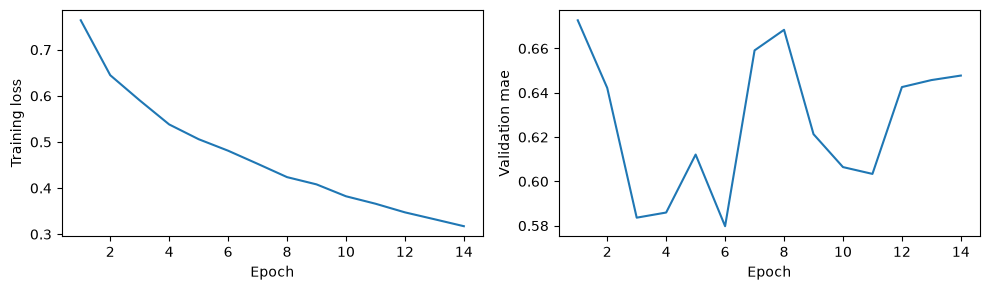

In [ ]:
# 可选：训练曲线。没有 matplotlib 时跳过，不影响模型训练。
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("未安装 matplotlib；曲线数据已保存在 history.json")
else:
    metric = "macro_f1" if config.task == "classification" else "mae"
    epochs = [r["epoch"] for r in experiment.history]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(epochs, [r["train_loss"] for r in experiment.history])
    axes[0].set(xlabel="Epoch", ylabel="Training loss")
    axes[1].plot(epochs, [r["valid"][metric] for r in experiment.history])
    axes[1].set(xlabel="Epoch", ylabel="Validation " + metric)
    fig.tight_layout()
    plt.show()

# Attention way

In [ ]:
import pickle
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from multi_fusion_model.context_lstm_fusion import (
    Config as LSTMConfig,
    fit_experiment as fit_lstm_experiment,
    explain_feature_groups as explain_lstm_features,
    load_experiment_model as load_lstm_model,
    predict_split as predict_lstm_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

## 2. 两级结构与分阶段训练

```text
text   [B,50,768] → 独立 BiLSTM → Dense(ReLU) → [B,50,128] ┐
audio  [B,50,74]  → 独立 BiLSTM → Dense(ReLU) → [B,50,128] ├→ 按原槽位拼接 [B,50,384]
vision [B,50,35]  → 独立 BiLSTM → Dense(ReLU) → [B,50,128] ┘
  → 融合 BiLSTM → Dense(ReLU) [B,50,128] → masked mean → 分类头 [B,3]
```

默认 `training_mode="staged"`：

1. 三个分支各自用 masked pooling + 临时分类头训练，用验证集选择各自最佳参数。
2. 冻结三路分支及其 dropout，训练融合 LSTM 与最终头，再由验证集选择最佳模型。
3. 加载所选模型后，统一评估一次测试集。

预训练和融合都使用每样本标签。默认每分支最多 20 轮、融合最多 40 轮，即最多 100 轮小模型训练，各阶段都有 early stopping。`train` 和 `valid` 各模态至少需要一个有观测的样本。

`bidirectional=False` 可改为单向；`training_mode="joint"` 会跳过分支预训练、联合训练整个网络，这是另一实验设置。默认三分类；`task="regression"` 改用回归标签和 MAE。分类的类别编号不会被自动赋予正负面语义。


In [ ]:
lstm_config = LSTMConfig(
    task="regression",
    hidden_dim=128,
    context_dim=128,
    fusion_hidden_dim=128,
    fusion_context_dim=128,
    bidirectional=True,
    dropout=0.2,
    pooling="mean",
    training_mode="staged",
    pretrain_epochs=20,
    pretrain_patience=5,
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    seed=42,
     output_root=str(os.path.join(MODULE_DIR , "context_lstm_fusion")),
)

lstm_experiment = fit_lstm_experiment(data, lstm_config, mask_overrides=mask_overrides)


device=cuda; mode=staged; task=regression; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/context_lstm_fusion/20260924_222954_744988
Adaptation: within-sample time slots, masked pooling and a neural head; NOT inter-utterance context/SVM.
Default A/V masks share text positions; zero rows remain observations unless explicitly masked.
unimodal_text epoch 01 | train_loss=0.7282 | valid_mae=0.6486
unimodal_text epoch 02 | train_loss=0.6212 | valid_mae=0.5986
unimodal_text epoch 03 | train_loss=0.5739 | valid_mae=0.5974
unimodal_text epoch 04 | train_loss=0.5277 | valid_mae=0.6110
unimodal_text epoch 05 | train_loss=0.4841 | valid_mae=0.6042
unimodal_text epoch 06 | train_loss=0.4441 | valid_mae=0.6091
unimodal_text epoch 07 | train_loss=0.4079 | valid_mae=0.6141
unimodal_text epoch 08 | train_loss=0.3782 | valid_mae=0.6126
unimodal_audio epoch 01 | train_loss=0.8271 | valid_mae=0.7736
unimodal_audio epoch 02 | train_loss=0.8139 | valid_mae=0.77

## 3. 检查预测与中间形状

数据处理复用先前 Weighted Sum 的代码，音视频标准化参数只在训练集拟合；这里只复用工具，没有调用 Weighted Sum 的模型。

输出目录记录所有阶段训练曲线、最佳模型、验证和测试指标，以及含样本 ID 的预测文件。`test_predictions.npz` 还保存最终 pooled features。融合 LSTM 是非线性的，**没有可加和的三路权重贡献**，不要套用 Weighted Sum 的分数分解。


In [ ]:
import torch

print("类别映射:", lstm_experiment.class_values)
print("各分支所选轮次:", {m: x["epoch"] for m, x in lstm_experiment.pretraining.items()})
print("验证集:", lstm_experiment.valid_metrics)
print("测试集:", lstm_experiment.test_metrics)
print("输出目录:", lstm_experiment.run_dir)

item = lstm_experiment.datasets["test"][0]
device = next(lstm_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
with torch.no_grad():
    output = lstm_experiment.model(features, masks)
for m, sequence in output["unimodal_sequences"].items():
    print(m, "上下文特征:", tuple(sequence.shape))
for key in ("concatenated", "fusion_sequence", "pooled_features", "logits"):
    print(key, tuple(output[key].shape))


类别映射: [0.0, 1.0, 2.0]
各分支所选轮次: {'text': 2, 'audio': 7, 'vision': 15}
验证集: {'accuracy': 0.5934065934065934, 'macro_f1': 0.5538179768949, 'weighted_f1': 0.5831479382831876, 'per_class_f1': [0.554945054945055, 0.41420118343195267, 0.6923076923076923], 'confusion_matrix': [[101, 34, 71], [30, 70, 84], [27, 50, 261]], 'loss': 1.16907799243927}
测试集: {'accuracy': 0.6107290233837689, 'macro_f1': 0.5468505745351804, 'weighted_f1': 0.5985415346627965, 'per_class_f1': [0.6070460704607046, 0.31690140845070425, 0.7166042446941323], 'confusion_matrix': [[112, 34, 61], [22, 45, 91], [28, 47, 287]], 'loss': 1.1223737001419067}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/context_lstm_fusion/20260924_152814_009415
text 上下文特征: (1, 50, 128)
audio 上下文特征: (1, 50, 128)
vision 上下文特征: (1, 50, 128)
concatenated (1, 50, 384)
fusion_sequence (1, 50, 128)
pooled_features (1, 128)
logits (1, 3)


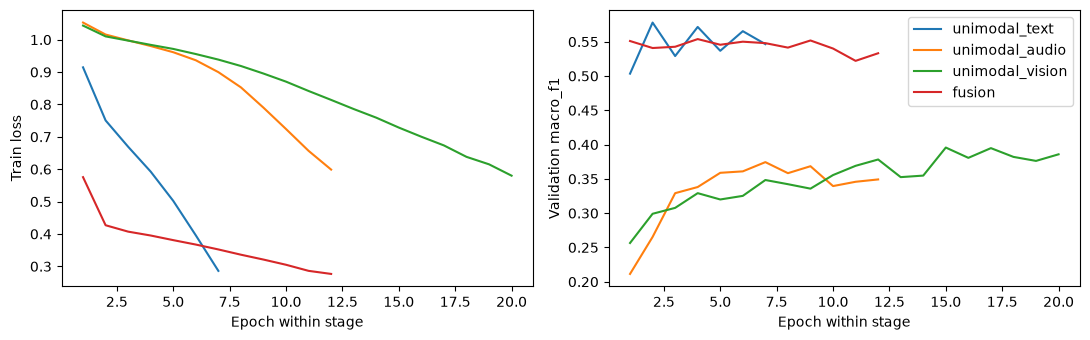

In [ ]:
# 可选：分阶段训练曲线；没有 matplotlib 也能完成训练。
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = lstm_experiment.history
    stages = list(dict.fromkeys(record["stage"] for record in history))
    metric = "macro_f1" if lstm_config.task == "classification" else "mae"
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    for stage in stages:
        records = [record for record in history if record["stage"] == stage]
        epochs = [record["epoch"] for record in records]
        axes[0].plot(epochs, [record["train_loss"] for record in records], label=stage)
        axes[1].plot(epochs, [record["valid"][metric] for record in records], label=stage)
    axes[0].set(xlabel="Epoch within stage", ylabel="Train loss")
    axes[1].set(xlabel="Epoch within stage", ylabel=f"Validation {metric}")
    axes[1].legend()
    fig.tight_layout()
    plt.show()


# Ren 2021：交互注意力


接着已经加载好的 `data` 运行。下面按 Poria 示例的顺序组织：导入 → 结构与训练 → 中间形状 → 训练曲线。

**实现范围：**原方法面向会话情绪识别，你的数据是每样本 50 个对齐位置、一个标签，没有会话分组和说话人身份。当前采用样本内、单主体的 IMAN 思路适配。已核实[作者摘要](https://doi.org/10.1109/LSP.2021.3078698)中的交互注意力和状态建模组件，但未核实全文方程；下述六向注意力、残差更新和状态递推是明确的实现设计。

这里按最终预测损失**联合训练**，不使用 Poria 的 `staged`、单模态预训练或冻结阶段。

In [ ]:
import pickle
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from multi_fusion_model.ren2021_fusion import (
    Config as RenConfig,
    fit_experiment as fit_ren_experiment,
    explain_feature_groups as explain_ren_features,
    load_experiment_model as load_ren_model,
    predict_split as predict_ren_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先执行已有的数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

## 2. 交互注意力与联合训练

```text
text   [B,50,768] → 独立投影 → [B,50,128] ┐
audio  [B,50,74]  → 独立投影 → [B,50,128] ├→ 六向跨模态注意力
vision [B,50,35]  → 独立投影 → [B,50,128] ┘

text 查询 audio / vision → 更新后的 text   [B,50,128]
audio 查询 text / vision → 更新后的 audio  [B,50,128]
vision 查询 text / audio → 更新后的 vision [B,50,128]
                             ↓
每个位置计算三路模态权重 [B,50,3]
                             ↓
按模态加权融合 → [B,50,128]
                             ↓
context / entity / emotion 三状态 GRU
                             ↓
情绪状态序列 [B,50,128] → masked mean [B,128] → 分类头 [B,3]
```

每个 query 位置可以读取另一模态的整个有效序列；随后模态权重在同一位置的三路表示间归一化。单主体 entity 状态是当前数据的适配，不表示真实多说话人识别。无效位置不更新 GRU 状态。
训练时最终 CE 同时更新投影、注意力、模态选择、三种 GRU 和分类头。最多 40 轮，以验证集 Macro-F1 选择模型；连续 8 轮不提升则早停，之后加载最佳权重并评估测试集。task="regression" 切换到回归标签、MAE 训练和验证集 MAE 选模。
默认沿用 text_bert[:,1,:] 的共享 mask；前提是三路槽位布局一致，包括特殊 token 的位置。独立有效性记录仍通过 mask_overrides 传入，全零音视频不自动视为缺失。音视频标准化只拟合训练集。

In [ ]:
ren_config = RenConfig(
    task="regression",
    d_model=128,
    nhead=4,
    dropout=0.2,
    pretrain_epochs=0,
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "ren2021_fusion")),
)

ren_experiment = fit_ren_experiment(
    data, ren_config, mask_overrides=mask_overrides,
)


model=ren2021; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/ren2021_fusion/ren2021/20260924_223404_417418
Implementation scope: IMAN components / single-entity within-sample adaptation
supervised_auxiliary_weights={}; pretrain_auxiliary_weights={}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=0.7290 | valid_mae=0.6447
epoch 02 | loss=0.6403 | valid_mae=0.5999
epoch 03 | loss=0.5907 | valid_mae=0.6225
epoch 04 | loss=0.5510 | valid_mae=0.5952
epoch 05 | loss=0.5270 | valid_mae=0.5962
epoch 06 | loss=0.4934 | valid_mae=0.6086
epoch 07 | loss=0.4632 | valid_mae=0.6013
epoch 08 | loss=0.4397 | valid_mae=0.6247
epoch 09 | loss=0.4096 | valid_mae=0.6833
epoch 10 | loss=0.3877 | valid_mae=0.6541
epoch 11 | loss=0.3734 | valid_mae=0.6358
epoch 12 | loss=0.3422 | valid_mae=0.6771
Selected epoch: 4 Test: {'mae': 0.6729312539100647, 'rmse': 

## 3. 检查预测与中间形状
return_intermediates=True 返回供检查的中间特征，默认已 detach。unimodal_sequences 是经过跨模态交互更新后的三路序列；fusion_sequence 是模态选择后的融合序列；emotion_sequence 是 GRU 输出。它们仍保留原来的 50 个位置。
modality_attention 是内部信息选择权重，不能当成对最终分类的贡献百分比。输出类别列顺序由 class_values 给出，不自动指定 0/1/2 的情绪语义。

In [ ]:
print("类别映射:", ren_experiment.class_values)
import json
metrics_record = json.loads((ren_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳验证轮次:", metrics_record["selected_epoch"])
print("验证集:", ren_experiment.valid_metrics)
print("测试集:", ren_experiment.test_metrics)
print("输出目录:", ren_experiment.run_dir)

item = ren_experiment.datasets["test"][0]
device = next(ren_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}

ren_experiment.model.eval()
with torch.no_grad():
    ren_output = ren_experiment.model(features, masks, return_intermediates=True)

for m, sequence in ren_output["unimodal_sequences"].items():
    print(m, "交互后特征:", tuple(sequence.shape))
for key in (
    "modality_attention", "fusion_sequence", "context_sequence", "entity_sequence",
    "emotion_sequence", "pooled_features", "logits",
):
    print(key, tuple(ren_output[key].shape))


类别映射: [0.0, 1.0, 2.0]
最佳验证轮次: 4
验证集: {'accuracy': 0.6387362637362637, 'macro_f1': 0.6033472852760556, 'weighted_f1': 0.6292585431872899, 'per_class_f1': [0.6561679790026247, 0.43558282208588955, 0.7182910547396528], 'confusion_matrix': [[125, 29, 52], [23, 71, 90], [27, 42, 269]], 'loss': 0.9449186325073242}
测试集: {'accuracy': 0.6671251719394773, 'macro_f1': 0.6023855077264725, 'weighted_f1': 0.6518724324702537, 'per_class_f1': [0.672, 0.373134328358209, 0.7620221948212084], 'confusion_matrix': [[126, 28, 53], [21, 50, 87], [21, 32, 309]], 'loss': 0.8503979444503784}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/ren2021_fusion/ren2021/20260924_184048_284026
text 交互后特征: (1, 50, 128)
audio 交互后特征: (1, 50, 128)
vision 交互后特征: (1, 50, 128)
modality_attention (1, 50, 3)
fusion_sequence (1, 50, 128)
context_sequence (1, 50, 128)
entity_sequence (1, 50, 128)
emotion_sequence (1, 50, 128)
pooled_features (1, 128)
logits (1, 3)


## 4. 训练曲线
这个模型只有一个联合训练阶段，因此不画 Poria 的分阶段曲线。左图对照训练/验证损失，右图显示用于选择模型的验证指标。历史记录的 train_loss 与前面的 Poria 用法一致，完整记录保存为 history.json。

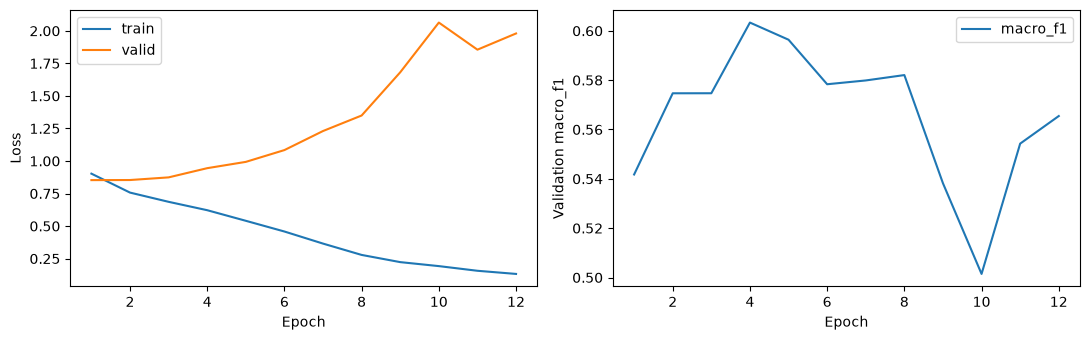

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = ren_experiment.history
    epochs = [record["epoch"] for record in history]
    metric = "macro_f1" if ren_config.task == "classification" else "mae"

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(epochs, [record["train_loss"] for record in history], label="train")
    axes[0].plot(epochs, [record["valid"]["loss"] for record in history], label="valid")
    axes[0].set(xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    axes[1].plot(epochs, [record["valid"][metric] for record in history], label=metric)
    axes[1].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    axes[1].legend()
    fig.tight_layout()
    plt.show()


# Zheng 2022：级联多头注意力与共享融合自编码器

接着已有的 `data` 运行。按 Poria / Ren 示例组织：导入 → 结构与训练 → 中间形状 → 训练曲线 → 可选遮挡与重载。

本次更新了公共训练器。若当前内核已导入过旧版 `multimodal_suite`，请先重启内核，然后重新运行数据加载、已有的 mask 设置和本节，避免继续使用内存中的旧模块。

实现依据：[作者全文，§III-B/C 与 §IV-C](https://www.researchgate.net/publication/358111733_Multi-channel_Weight-sharing_Autoencoder_Based_on_Cascade_Multi-head_Attention_for_Multimodal_Emotion_Recognition)，[DOI](https://doi.org/10.1109/TMM.2022.3144885)。保留三条级联路径、双向跨模态注意力、拼接与卷积、共享融合层与三路重构，以及无监督预训练后监督微调。

**实现范围：**这是适用于你现有 `[N,50,768/74/35]` 缓存特征的版本。独立投影与残差 Conv1d/self-attention 编码器替代原文原始信号编码器；decoder 重建缓存特征，音视频重建目标处在训练集拟合的标准化空间。使用 masked mean 生成样本级预测，不复现原文原始信号重建或 LTPP。下面的宽度、3 轮预训练等是可调默认值，不是原文超参数。


In [ ]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.zheng2022_fusion import (
    Config as ZhengConfig,
    fit_experiment as fit_zheng_experiment,
    explain_feature_groups as explain_zheng_features,
    load_experiment_model as load_zheng_model,
    predict_split as predict_zheng_split,
    audit_data,
)

In [ ]:
pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

In [ ]:
mask_overrides = None

# 有经过确认的标记时，改为下面的结构；不要用“特征全零”直接替代真实标记。
# mask_overrides = {
#     "train": {"audio": train_audio_valid, "vision": train_vision_valid},
#     "valid": {"audio": valid_audio_valid, "vision": valid_vision_valid},
#     "test":  {"audio": test_audio_valid,  "vision": test_vision_valid},
# }
# 每个数组形状 [N,50]，bool 或 0/1；可另加 "text" 覆盖文本标记。

report = audit_data(data, mask_overrides)

for split, detail in report.items():
    print("\n", split, detail["samples"])
    for modality, r in detail["modalities"].items():
        print(modality, r["shape"],
              "mask来源:", r["mask_source"],
              "文本有效区全零:", r["zero_in_text_valid_region"],
              "文本padding区非零:", r["nonzero_in_text_padding_region"])



 train 3395
text [3395, 50, 768] mask来源: text_bert[:,1,:] 文本有效区全零: 0 文本padding区非零: 86078
audio [3395, 50, 74] mask来源: text_bert[:,1,:] 文本有效区全零: 6855 文本padding区非零: 0
vision [3395, 50, 35] mask来源: text_bert[:,1,:] 文本有效区全零: 11039 文本padding区非零: 0

 valid 728
text [728, 50, 768] mask来源: text_bert[:,1,:] 文本有效区全零: 0 文本padding区非零: 17772
audio [728, 50, 74] mask来源: text_bert[:,1,:] 文本有效区全零: 1502 文本padding区非零: 0
vision [728, 50, 35] mask来源: text_bert[:,1,:] 文本有效区全零: 2436 文本padding区非零: 0

 test 727
text [727, 50, 768] mask来源: text_bert[:,1,:] 文本有效区全零: 0 文本padding区非零: 18041
audio [727, 50, 74] mask来源: text_bert[:,1,:] 文本有效区全零: 1454 文本padding区非零: 0
vision [727, 50, 35] mask来源: text_bert[:,1,:] 文本有效区全零: 2478 文本padding区非零: 0


## 2. 三条级联路径与两个训练阶段

```text
text   [B,50,768] → 独立投影 + 序列编码 → T [B,50,128]
audio  [B,50,74]  → 独立投影 + 序列编码 → A [B,50,128]
vision [B,50,35]  → 独立投影 + 序列编码 → V [B,50,128]

Pair(X,Y) = Conv1x1(concat(MHA(Q=X,K=Y,V=Y), MHA(Q=Y,K=X,V=X)))
            两个方向各 [B,50,128] → 拼接 [B,50,256] → [B,50,128]

Pair(A,T) → Pair(AT,V) → ATV [B,50,128] ┐
Pair(A,V) → Pair(AV,T) → AVT [B,50,128] ├→ concat [B,50,384]
Pair(T,V) → Pair(TV,A) → TVA [B,50,128] ┘
                                              ↓ Conv1x1
                                      共享融合表示 [B,50,128]
                                      ├→ text decoder   → [B,50,768]
                                      ├→ audio decoder  → [B,50,74]
                                      ├→ vision decoder → [B,50,35]
                                      └→ masked mean → [B,128] → 分类头 [B,3]
```

每个 query 可读取另一序列的全部有效位置，随后按原槽位拼接两个方向的输出。三条路径和两个方向的注意力参数各自独立。“权重共享”指三路重构与预测使用同一个融合网络，三个 decoder 各自独立。

默认训练流程：

1. **重构预训练，3 轮：**只读取训练集，损失为三个模态的 masked MSE 之和，各模态分别除以有效元素数。更新投影、编码器、融合网络和 decoder，不训练分类头。预训练为固定轮数，不使用验证集选轮。
2. **监督微调，最多 40 轮：**继承预训练权重，用分类 CE 更新投影、编码器、融合网络和分类头；默认不加重构损失，decoder 不更新。以验证集 Macro-F1 选模、早停，再加载最佳模型统一评估测试集。`task="regression"` 改为 MAE 训练和选模。

`pretrain_epochs=0` 可跳过预训练。微调时设置 `auxiliary_weights={"reconstruction": 0.1}` 可做“任务 + 重构”联合损失实验；这是额外实验设置。当前默认不冻结预测路径。

沿用既有数据工具：音视频标准化仅拟合训练集；默认共享 `text_bert[:,1,:]` mask，前提是三路槽位布局一致（包括特殊 token 位置）；独立有效性记录通过 `mask_overrides` 传入。全零音视频不自动判缺失。整条模态缺失时保留另一条有效流，这是本实现的缺失处理适配。


In [ ]:
zheng_config = ZhengConfig(
    task="regression",
    d_model=128,
    nhead=4,
    dropout=0.2,
    pretrain_epochs=3,
    pretrain_auxiliary_weights={"reconstruction": 1.0},
    auxiliary_weights={"reconstruction": 0.0},
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "zheng2022_fusion")),
)

zheng_experiment = fit_zheng_experiment(
    data, zheng_config, mask_overrides=mask_overrides,
)

model=zheng2022; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/zheng2022_fusion/zheng2022/20260924_223759_800951
Implementation scope: Cascade multi-head attention and shared-latent autoencoder adaptation
supervised_auxiliary_weights={'reconstruction': 0.0}; pretrain_auxiliary_weights={'reconstruction': 1.0}; auxiliary_pretrain_epochs=3
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
pretrain 01 | loss=1.8240
pretrain 02 | loss=1.3234
pretrain 03 | loss=1.1891
epoch 01 | loss=0.8020 | valid_mae=0.6545
epoch 02 | loss=0.6747 | valid_mae=0.6569
epoch 03 | loss=0.6214 | valid_mae=0.6814
epoch 04 | loss=0.5694 | valid_mae=0.5907
epoch 05 | loss=0.5232 | valid_mae=0.5902
epoch 06 | loss=0.5086 | valid_mae=0.5880
epoch 07 | loss=0.4741 | valid_mae=0.5645
epoch 08 | loss=0.4509 | valid_mae=0.5829
epoch 09 | loss=0.4255 | valid_mae=0.5642
epoch 10 | loss=0.4038 | valid_mae=0.5810
epoch

## 3. 检查预测、三条路径与重构形状

`return_intermediates=True` 额外返回已 detach 的中间特征和重构结果；默认评估只走预测路径。重构输出的无效位置置零；重构 MSE 只统计有效位置，整条模态都无效时该项为零。

输出目录保存配置、mask 审计、标准化参数、预训练及最佳监督权重、各阶段 history、验证/测试指标与带 ID 的预测。类别列顺序看 `class_values`，不自动给 0/1/2 赋予情绪语义。


In [ ]:
print("类别映射:", zheng_experiment.class_values)
metrics_record = json.loads((zheng_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳监督轮次:", metrics_record["selected_epoch"])
print("验证集:", zheng_experiment.valid_metrics)
print("测试集:", zheng_experiment.test_metrics)
print("输出目录:", zheng_experiment.run_dir)

item = zheng_experiment.datasets["test"][0]
device = next(zheng_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}

zheng_experiment.model.eval()
with torch.no_grad():
    zheng_output = zheng_experiment.model(features, masks, return_intermediates=True)

for group in ("encoded_sequences", "pair_sequences", "cascade_sequences", "reconstructions"):
    print("\n" + group)
    for name, sequence in zheng_output[group].items():
        print(name, tuple(sequence.shape))
for key in ("concatenated", "fusion_sequence", "pooled_features", "logits"):
    print(key, tuple(zheng_output[key].shape))
print("各路有效位置重构 MSE:", {
    m: float(loss) for m, loss in zheng_output["reconstruction_losses"].items()
})


类别映射: [0.0, 1.0, 2.0]
最佳监督轮次: 5
验证集: {'accuracy': 0.6126373626373627, 'macro_f1': 0.5895589955500423, 'weighted_f1': 0.6114770380151419, 'per_class_f1': [0.6495327102803738, 0.43454038997214484, 0.6846038863976084], 'confusion_matrix': [[139, 38, 29], [33, 78, 73], [50, 59, 229]], 'loss': 0.9524540901184082}
测试集: {'accuracy': 0.6698762035763411, 'macro_f1': 0.6216819095595089, 'weighted_f1': 0.6639219679237708, 'per_class_f1': [0.7098214285714286, 0.40418118466898956, 0.7510431154381085], 'confusion_matrix': [[159, 27, 21], [34, 58, 66], [48, 44, 270]], 'loss': 0.8740403056144714}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/zheng2022_fusion/zheng2022/20260924_191336_568237

encoded_sequences
text (1, 50, 128)
audio (1, 50, 128)
vision (1, 50, 128)

pair_sequences
audio_text (1, 50, 128)
audio_vision (1, 50, 128)
text_vision (1, 50, 128)

cascade_sequences
audio_text_vision (1, 50, 128)
audio_vision_text (1, 50, 128)
text_vision_audio (1,

## 4. 分阶段训练曲线

预训练没有验证分类指标。左图显示预训练的三路 MSE 总和，中图显示监督阶段的任务损失，右图显示选模指标。两个阶段使用各自的轮次；完整训练总损失也保存在 `history.json` 的 `train_loss`。


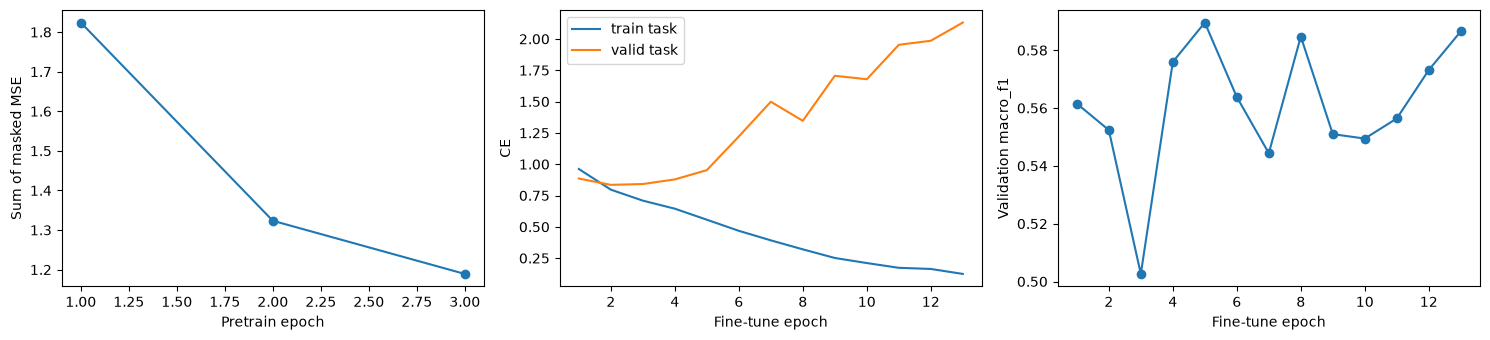

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = zheng_experiment.history
    pretraining = [r for r in history if r["stage"] == "auxiliary_pretrain"]
    supervised = [r for r in history if r["stage"] == "supervised"]
    metric = "macro_f1" if zheng_config.task == "classification" else "mae"
    task_loss = "CE" if zheng_config.task == "classification" else "MAE"
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    if pretraining:
        axes[0].plot([r["epoch"] for r in pretraining],
                     [r["train"]["reconstruction"] for r in pretraining], marker="o")
    else:
        axes[0].text(0.5, 0.5, "Pretraining skipped", ha="center", transform=axes[0].transAxes)
    axes[0].set(xlabel="Pretrain epoch", ylabel="Sum of masked MSE")
    epochs = [r["epoch"] for r in supervised]
    axes[1].plot(epochs, [r["train"]["supervised"] for r in supervised], label="train task")
    axes[1].plot(epochs, [r["valid"]["loss"] for r in supervised], label="valid task")
    axes[1].set(xlabel="Fine-tune epoch", ylabel=task_loss)
    axes[1].legend()
    axes[2].plot(epochs, [r["valid"][metric] for r in supervised], marker="o")
    axes[2].set(xlabel="Fine-tune epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


# Pan 2020：模态注意力与四分支晚期融合

接着已经加载好的 `data` 运行，保持 Poria / Ren / Zheng 的组织方式。

实现依据：[ISCA 原文](https://www.isca-archive.org/interspeech_2020/pan20b_interspeech.pdf)，图 1–2、公式 1–4 和 §2.2。Pan 的注意力在**同一个位置的三种模态之间**归一化，得到三种 query 各自的加权表示。注意力输出与原投影拼接，进入 cLSTM-MMA；完整 MMAN 再融合这个分支与三个单模态 cLSTM 的预测。

**适配范围：**原文沿会话中的 utterance 建模；这里沿每条样本的 50 个对齐槽位建模，通过 masked mean 输出一个样本标签。使用已有 BERT / 音频 / 视觉缓存特征，不重做原文特征提取。本实现取 `dq=dk=dv=d_model`，三个 query 各自独立，K/V 按来源模态共享；原文未明确说明跨方向 K/V 是否共享，这是这里采用的参数约定。投影中的 LayerNorm/GELU、隐藏 Dense 的宽度及 ReLU 是当前适配设置。

本次更新了注意力模块。若内核已导入旧版 `multimodal_suite`，先重启内核，再运行数据加载、原有 mask 设置和本节。

In [ ]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.pan2020_fusion import (
    Config as PanConfig,
    fit_experiment as fit_pan_experiment,
    explain_feature_groups as explain_pan_features,
    load_experiment_model as load_pan_model,
    predict_split as predict_pan_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先执行已有的数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

## 2. 同槽位注意力、四个分支与分阶段训练

```text
MMA 分支：
text   [B,50,768] → 独立投影 → T [B,50,128]
audio  [B,50,74]  → 独立投影 → A [B,50,128]
vision [B,50,35]  → 独立投影 → V [B,50,128]

每个位置 t：
T[t] 查询 {T[t], A[t], V[t]} → Z_T[t] [B,128]
A[t] 查询 {T[t], A[t], V[t]} → Z_A[t] [B,128]
V[t] 查询 {T[t], A[t], V[t]} → Z_V[t] [B,128]
                    ↓
concat(Z_T,Z_A,Z_V,T,A,V) [B,50,768]
                    ↓
1 层单向 LSTM → [B,50,128] → masked mean → Dense(ReLU) → Dense → p_MMA [B,3]

三个独立单模态分支，各自拥有另一套投影参数：
text   → 投影 → 2 层单向 LSTM → masked mean → Dense(ReLU) → Dense → p_T [B,3]
audio  → 投影 → 2 层单向 LSTM → masked mean → Dense(ReLU) → Dense → p_A [B,3]
vision → 投影 → 2 层单向 LSTM → masked mean → Dense(ReLU) → Dense → p_V [B,3]

concat(p_MMA,p_T,p_A,p_V) [B,12] → 最终 Dense → logits [B,3]
```

分类时 `p` 是各分支的 softmax 概率，最终输出仍为 logits，交给 CrossEntropyLoss。回归时使用各分支的实数预测。所有注意力轴的模态顺序固定为 `text, audio, vision`；分支顺序为 `multimodal, text, audio, vision`。

默认 `training_mode="staged"`：

1. 四个分支各自用样本标签监督训练，每支最多 20 轮、patience=5，各自用验证集选最佳权重。四个分支的参数互不共享。
2. 冻结四个分支的参数及 dropout，只训练末端 Dense，最多 40 轮、patience=8，以验证集 Macro-F1 选模。
3. 加载所选模型后统一评估一次测试集。`task="regression"` 切换为 MAE 训练和选模。

最多为 4×20+40=120 轮分阶段训练；这里的超参数是本次默认设置。`training_mode="joint"` 切换到额外实验：最终任务损失 + `branch_loss_weight` × 四分支任务损失均值，联合更新全部参数。此时 `pretrain_epochs` 不使用。Pan 不包含 Zheng 式重构预训练，不使用 `nhead` 参数。

音视频标准化仅拟合训练集。默认共享 `text_bert[:,1,:]` mask，前提是槽位布局连同特殊 token 占位都一致；可通过 `mask_overrides` 提供独立有效性记录，全零行不自动判缺失。某样本整条模态缺失时，其单模态分支预测置零、分支监督跳过该样本；staged 要求 train 和 valid 中每种模态都至少有一个有观测样本。


In [ ]:
pan_config = PanConfig(
    task="regression",
    d_model=128,
    lstm_hidden=128,
    unimodal_layers=2,
    dropout=0.2,
    training_mode="staged",
    pretrain_epochs=20,
    pretrain_patience=5,
    epochs=100,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    branch_loss_weight=1.0,  # 仅 joint 模式使用
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "pan2020_fusion")),
)

pan_experiment = fit_pan_experiment(data, pan_config, mask_overrides=mask_overrides)


device=cuda; Pan mode=staged; task=regression; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/pan2020_fusion/20260924_224015_225055
Adaptation: aligned within-sample slots and one sample target; not the paper's utterance-context evaluation.
A/V masks default to text positions; zero-valued features remain observations unless explicitly masked.
subnetwork_multimodal epoch 01 | train_loss=0.7474 | valid_mae=0.6383
subnetwork_multimodal epoch 02 | train_loss=0.6134 | valid_mae=0.6095
subnetwork_multimodal epoch 03 | train_loss=0.5641 | valid_mae=0.5986
subnetwork_multimodal epoch 04 | train_loss=0.5160 | valid_mae=0.6304
subnetwork_multimodal epoch 05 | train_loss=0.4900 | valid_mae=0.6080
subnetwork_multimodal epoch 06 | train_loss=0.4532 | valid_mae=0.5949
subnetwork_multimodal epoch 07 | train_loss=0.4293 | valid_mae=0.6372
subnetwork_multimodal epoch 08 | train_loss=0.4115 | valid_mae=0.5991
subnetwork_multimodal epoch 09 | train_loss=0.37

# M3ER 2020：CCA 筛查、代理特征与乘性融合

接着已加载的 `data` 运行。参考[论文全文 §3.3–3.5、§4.2](https://arxiv.org/html/1911.05659v2)，实现适用于现有 `[N,50,768/74/35]` 特征的版本。

**实现范围必须区分清楚：**

- CCA 在训练集的共同观测位置拟合，随后逐槽位筛查；使用正则化与 16 维投影。原文采用 100 维，而你的视觉特征只有 35 维。阈值 0、beta=2、拟合槽位上限等是本次设置，原文未报告这两个超参数的具体值。
- 原文代理算法使用配对基、近邻和展开系数迁移，公开描述未充分指定基对应与近邻求解细节。**这里明确采用训练集拟合的配对 ridge 线性映射替代，不能称为原代理算法的精确复现。** 多个来源生成的代理取均值。
- 时序网络保留三路 LSTM、前后 cell-state 的注意力、门控 memory 和隐藏状态乘积；memory 更新是紧凑 MFN 风格实现，候选和门网络做了简化，并增加输入投影。使用 32 维 LSTM、128 维 memory、64 维隐藏分类层；输出类别数由你的训练标签决定。
- 最终任务损失加上式（3）的单模态辅助损失，是本实现的训练连接方式；原文未充分说明式（3）如何接入最终分类头，不能将当前连接方式当作已核实的原版唯一实现。

本次更新了公共模型模块。如果内核已导入旧版 `multimodal_suite`，请先重启内核，再执行数据加载、已有 mask 设置和本节。


In [1]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.m3er2020_fusion import (
    Config as M3ERConfig,
    fit_experiment as fit_m3er_experiment,
    explain_feature_groups as explain_m3er_features,
    load_experiment_model as load_m3er_model,
    predict_split as predict_m3er_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先执行已有的数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

## 2. 结构、CCA 拟合和训练目标

```text
text [B,50,768] / audio [B,50,74] / vision [B,50,35]
                         ↓
三个配对 CCA：text-audio / text-vision / audio-vision
                         ↓
同槽位：与至少一个已观测伙伴的相关性 ≥ 阈值 → 保留原始特征
                         ↓
训练：筛查后直接进入网络；默认不生成代理
预测：对缺失或被剔除的模态，用保留的原始模态生成代理，多来源取均值
                         ↓
三路独立投影 → 三个 LSTMCell → h_T、h_A、h_V，各 [B,32]
                         ↘ 前后 cell-state 注意力与门控 → memory [B,128]
h_T ⊙ h_A ⊙ h_V [B,32] 与 memory [B,128]
                         ↓ 拼接 [B,160]
                      Dense(64,ReLU) → logits [B,3]
```

若某路整条序列都没有可用特征，隐藏状态乘积使用单位因子 1，并跳过该路辅助损失。

1. 音视频标准化仅在训练集拟合；三组 CCA 和六个方向的 ridge 映射也仅用训练集共同观测槽位拟合，不读取标签。参数、拟合计数与状态作为模型 buffer 保存，重载后直接用于预测。
2. 联合训练时使用 `L = CE(final_logits, y) + λ × L_M3ER`。三模态情况下，论文式（3）为 `L_M3ER = -sum_m p_m(y)^(beta/2) * log(p_m(y))`，来自新增单模态分类头。默认 λ=1；它不直接更新最终分类头和 memory 参数。此项单独最小化不保证真类概率增加，因此本实现同时保留最终分类 CE。
3. 以验证集 Macro-F1 选择最佳模型并早停，最后加载所选权重、统一评估测试集。**预测不读取真实标签，也不把三路类别概率直接相乘。** `task="regression"` 使用最终 MAE 与单模态 MAE 辅助项，这是额外回归适配。

没有 Zheng 式重构预训练，也没有 Pan 式冻结阶段；`pretrain_epochs=0`。CCA 拟合是一次统计估计，不是梯度预训练。

mask 仍表示原始观测；默认共享 `text_bert[:,1,:]`，前提是包含特殊 token 的槽位布局一致。独立有效性记录传给 `mask_overrides`，全零行不自动判缺失。CCA 是相关性筛查，不能证明某模态真的损坏。若同槽位所有配对都被拒绝，本实现保留相关分数最高的一路原始观测，并用 `cca_fallback` 标记；没有可比较伙伴时保留未被检验的观测。共同观测少于 3 个槽位的配对不启用 CCA/代理。


In [2]:
m3er_config = M3ERConfig(
    task="regression",
    d_model=32,
    dropout=0.2,
    pretrain_epochs=0,
    model_options={
        "m3er_memory_dim": 128,
        "m3er_classifier_hidden": 64,
        "m3er_cca_components": 16,
        "m3er_cca_threshold": 0.0,
        "m3er_ridge": 0.01,
        "m3er_fit_max_slots": 8192,
        "m3er_fit_seed": 1729,
        "m3er_beta": 2.0,
        "m3er_proxy_during_training": False,
    },
    auxiliary_weights={
        "m3er_multiplicative": 1.0,
        "m3er_unimodal_regression": 0.1,  # 仅回归任务使用
    },
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "m3er2020_fusion")),
)

m3er_experiment = fit_m3er_experiment(data, m3er_config, mask_overrides=mask_overrides)

model=m3er2020; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/m3er2020_fusion/m3er2020/20260924_224437_756287
Implementation scope: CCA screening, sourced proxies, memory and multiplicative objective adaptation
supervised_auxiliary_weights={'m3er_multiplicative': 1.0, 'm3er_unimodal_regression': 0.1}; pretrain_auxiliary_weights={'m3er_multiplicative': 1.0, 'm3er_unimodal_regression': 0.1}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=0.9062 | valid_mae=0.7013
epoch 02 | loss=0.8030 | valid_mae=0.6412
epoch 03 | loss=0.7332 | valid_mae=0.6276
epoch 04 | loss=0.6869 | valid_mae=0.6791
epoch 05 | loss=0.6523 | valid_mae=0.6102
epoch 06 | loss=0.6290 | valid_mae=0.6047
epoch 07 | loss=0.6039 | valid_mae=0.6167
epoch 08 | loss=0.5757 | valid_mae=0.6216
epoch 09 | loss=0.5632 | valid_mae=0.6187
epoch 10 | loss=0.5450 | valid_mae=0.6078
e

## 3. 检查 CCA、代理来源和中间形状

所有 mask 最后一个轴均按 `text, audio, vision` 排列。`observed_masks` 是原始有效性；`cca_rejected_masks` 是检查未通过的位置；`effective_masks` 是最终保留的原始观测（含明确标记的 fallback）；`proxy_masks` 是生成位置；`usable_masks` 是网络实际使用的位置。它们互相区分，代理不冒充原始观测。

`proxy_sources[B,50,target,source]` 记录每个代理来自哪种原始模态。代理只用同槽位保留的原始特征生成，不递归使用新代理。`cca_pair_checked=False` 时，`cca_pair_scores` 中的 0 只是占位，不是有效相关系数。


In [ ]:
print("类别映射:", m3er_experiment.class_values)
metrics_record = json.loads((m3er_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
config_record = json.loads((m3er_experiment.run_dir / "config.json").read_text(encoding="utf-8"))
print("CCA / 代理拟合:", config_record["preprocessing_report"])
print("最佳轮次:", metrics_record["selected_epoch"])
print("验证集:", m3er_experiment.valid_metrics)
print("测试集:", m3er_experiment.test_metrics)
print("输出目录:", m3er_experiment.run_dir)

item = m3er_experiment.datasets["test"][0]
device = next(m3er_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
m3er_experiment.model.eval()
with torch.no_grad():
    m3er_output = m3er_experiment.model(features, masks, return_intermediates=True)

for group in ("filled_features", "unimodal_sequences"):
    print("\n" + group)
    for name, value in m3er_output[group].items():
        print(name, tuple(value.shape))
for key in ("cca_pair_scores", "proxy_sources", "final_hidden_states",
            "multiplicative_features", "memory_sequence", "memory", "pooled_features", "logits"):
    print(key, tuple(m3er_output[key].shape))

modalities = ("text", "audio", "vision")
for i, modality in enumerate(modalities):
    counts = {key: int(m3er_output[key][0, :, i].sum()) for key in (
        "observed_masks", "cca_rejected_masks", "effective_masks", "proxy_masks", "usable_masks"
    )}
    print(modality, counts)
print("全部拒绝后保留一路的位置数:", int(m3er_output["cca_fallback"][0].sum()))

proxy_positions = m3er_output["proxy_masks"][0].nonzero(as_tuple=False).cpu().tolist()
for t, target in proxy_positions[:15]:
    source_indices = m3er_output["proxy_sources"][0, t, target].nonzero(as_tuple=True)[0].cpu().tolist()
    print({"id": item["id"], "time_index": t, "generated_modality": modalities[target],
           "source_modalities": [modalities[j] for j in source_indices]})


类别映射: [0.0, 1.0, 2.0]
CCA / 代理拟合: {'fit_slots': {'text__audio': 8192, 'text__vision': 8192, 'audio__vision': 8192}, 'source_split': 'train', 'proxy_method': 'paired_ridge'}
最佳轮次: 16
验证集: {'accuracy': 0.5782967032967034, 'macro_f1': 0.5414118585821136, 'weighted_f1': 0.5728783344956866, 'per_class_f1': [0.5963060686015831, 0.34560906515580736, 0.6823204419889503], 'confusion_matrix': [[113, 52, 41], [25, 61, 98], [35, 56, 247]], 'loss': 1.8351054191589355}
测试集: {'accuracy': 0.6079779917469051, 'macro_f1': 0.5455025349784571, 'weighted_f1': 0.5988902822037561, 'per_class_f1': [0.6356968215158925, 0.2867132867132867, 0.7140974967061924], 'confusion_matrix': [[130, 34, 43], [34, 41, 83], [38, 53, 271]], 'loss': 1.6956169605255127}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/m3er2020_fusion/m3er2020/20260924_200001_035161

filled_features
text (1, 50, 768)
audio (1, 50, 74)
vision (1, 50, 35)

unimodal_sequences
text (1, 50, 32)
audio (1, 50,

## 4. 训练曲线

分别展示最终任务损失、式（3）辅助项（回归时为单模态 MAE）、验证选模指标。完整加权总损失保存在 `history.json` 的 `train_loss`。默认训练不补代理、验证补代理，因此二者的任务损失还反映输入处理的差别。


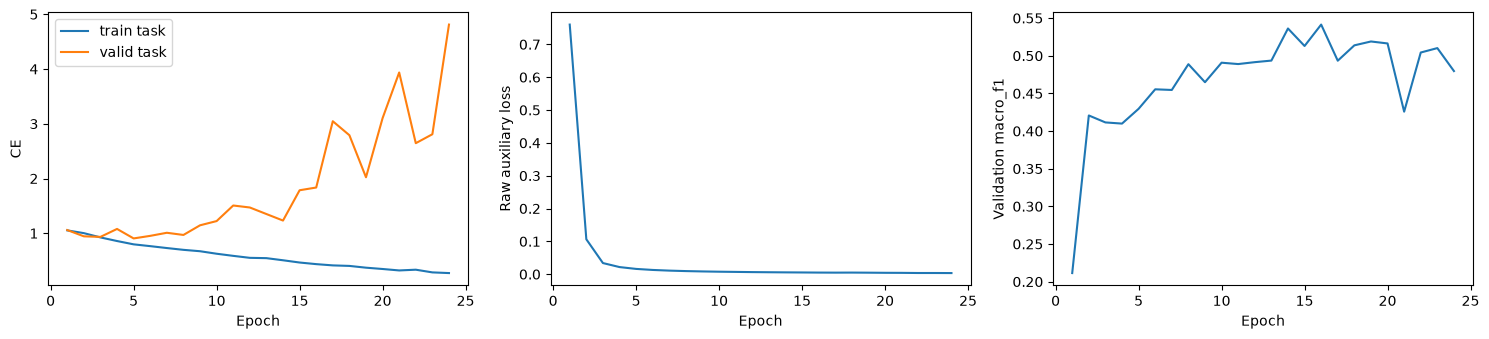

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = m3er_experiment.history
    epochs = [r["epoch"] for r in history]
    classification = m3er_config.task == "classification"
    metric = "macro_f1" if classification else "mae"
    aux_key = "m3er_multiplicative" if classification else "m3er_unimodal_regression"
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].plot(epochs, [r["train"]["supervised"] for r in history], label="train task")
    axes[0].plot(epochs, [r["valid"]["loss"] for r in history], label="valid task")
    axes[0].set(xlabel="Epoch", ylabel="CE" if classification else "MAE")
    axes[0].legend()
    axes[1].plot(epochs, [r["train"][aux_key] for r in history])
    axes[1].set(xlabel="Epoch", ylabel="Raw auxiliary loss")
    axes[2].plot(epochs, [r["valid"][metric] for r in history])
    axes[2].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


# MFRM 2022 思路适配：多路交互、声学时间选择与残差记忆

**这是 MFRM-inspired 特征级基线，不是原论文的逐公式复现。**

[论文 DOI](https://doi.org/10.1109/TAFFC.2020.3000510) 对应 2022 年卷期版 13(1):320–334。[作者公开仓库](https://github.com/TmacMai/MFRM_multimodal_sentiment_analysis)目前只有 README，未取得可核验的完整正文或作者实现。能确认的摘要级原则是同时间步融合、声学特征驱动的情感强度/变化关注、直接传递前一状态的残差记忆。

下面的三路 BiGRU、七路逐元素交互、声学评分、时间强调系数、残差更新与最终池化均是**本实现的明确设计**。结构图和公式准确描述代码，不作为原论文具体算子的证据。它使用你已有的 50 个对齐槽位及样本标签，适合先做受控对照实验。

本次增加了模型诊断接口。若内核已导入旧版 `multimodal_suite`，请先重启内核，再运行数据加载、原有 mask 设置和本节。


In [1]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.mfrm2022_fusion import (
    Config as MFRMConfig,
    fit_experiment as fit_mfrm_experiment,
    explain_feature_groups as explain_mfrm_features,
    load_experiment_model as load_mfrm_model,
    predict_split as predict_mfrm_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先执行已有的数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

## 2. 本实现的融合、时间选择和残差记忆

```text
text   [B,50,768] → 投影 → 独立 BiGRU → Dense(tanh) → T [B,50,128]
audio  [B,50,74]  → 投影 → 独立 BiGRU → Dense(tanh) → A [B,50,128]
vision [B,50,35]  → 投影 → 独立 BiGRU → Dense(tanh) → V [B,50,128]

同槽位构造七路：T, A, V, T⊙A, T⊙V, A⊙V, T⊙A⊙V
                         ↓ concat [B,50,896]
                      Dense(GELU) → F [B,50,128]
                         ↓ 声学时间强调
                      U [B,50,128]
                         ↓ 残差记忆递推
                      H [B,50,128]
                         ↓
concat(mean(H), final_memory, mean(T), mean(A), mean(V)) [B,640]
                         ↓
                    Dense(GELU) → logits [B,3]
```

声学时间强调的具体设计：

- 从声学上下文表示提取 `abs(A_t)` 和 `abs(A_t - A_prev_observed)`。首个有效音频位置的差分为 0；中间缺失位置不会被当作零声音用于制造变化。
- 将两者输入 MLP 得到分数，仅在有音频观测的位置沿时间 softmax，得到 `alpha[B,50]`。
- `U_t = F_t * (1 + gain * n_audio * alpha_t)`，其中 `n_audio` 是该样本有效音频槽位数。缺失音频位置的系数为 1；整条音频缺失时 alpha 全零，其他模态仍参与预测。

这里使用的是 **BiGRU 隐藏表示的幅度与变化**，包含双向上下文；不是物理音量，不是已测得的情感强度，也不能把 alpha 当成最终判断的贡献比例。

残差记忆的具体设计（本实现公式）：

```text
joint_t = concat(U_t, state_(t-1))
gate_t = sigmoid(W_g(joint_t))
candidate_t = tanh(W_u(joint_t))
update_t = Dropout(gate_t ⊙ candidate_t)
state_t = state_(t-1) + update_t
H_t = LayerNorm(state_t)
```

仅在三模态至少一路有效的位置更新 state；缺失位置直接携带上一状态，输出 H 置零。LayerNorm 用于读取，不切断原始残差携带路径。最终分类同时读取记忆和三路上下文均值，所以时间权重不是唯一预测通路。

按最终任务损失联合训练：分类 CE，验证集 Macro-F1 选模；`task="regression"` 改为 MAE 训练和选模。默认最多 40 轮、patience=8，选模后统一评估一次测试集。没有辅助损失、统计拟合阶段或分支冻结阶段，`pretrain_epochs=0`。`num_layers` 指各模态 BiGRU 的层数。

音视频标准化只拟合训练集。默认三路共享 `text_bert[:,1,:]`，前提是包含特殊 token 占位的槽位布局一致；独立 mask 通过 `mask_overrides` 提供，全零行不自动判缺失。缺失模态的相关乘积通道置零，不生成代理特征。全部模态均无观测的样本拒绝预测。


In [2]:
mfrm_config = MFRMConfig(
    task="regression",
    d_model=128,
    num_layers=1,
    dropout=0.2,
    pretrain_epochs=0,
    model_options={"mfrm_intensity_gain": 1.0},
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "mfrm2022_fusion")),
)

mfrm_experiment = fit_mfrm_experiment(data, mfrm_config, mask_overrides=mask_overrides)

model=mfrm2022; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/mfrm2022_fusion/mfrm2022/20260924_224748_966076
Implementation scope: MFRM-inspired residual-memory baseline
supervised_auxiliary_weights={}; pretrain_auxiliary_weights={}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=0.7364 | valid_mae=0.7088
epoch 02 | loss=0.6516 | valid_mae=0.6066
epoch 03 | loss=0.5867 | valid_mae=0.5998
epoch 04 | loss=0.5448 | valid_mae=0.5942
epoch 05 | loss=0.5322 | valid_mae=0.6467
epoch 06 | loss=0.5084 | valid_mae=0.5865
epoch 07 | loss=0.4738 | valid_mae=0.5933
epoch 08 | loss=0.4531 | valid_mae=0.5826
epoch 09 | loss=0.4216 | valid_mae=0.6031
epoch 10 | loss=0.4124 | valid_mae=0.6122
epoch 11 | loss=0.4072 | valid_mae=0.5996
epoch 12 | loss=0.3642 | valid_mae=0.6198
epoch 13 | loss=0.3524 | valid_mae=0.6222
epoch 14 | loss=0.3378 | valid_ma

## 3. 检查交互通道、时间权重和残差更新

`return_intermediates=True` 返回用于检查的已 detach 诊断张量。`interaction_masks` 可核对某个乘积通道是否真的有对应模态观测。

`memory_state_sequence` 是未归一化的累积状态，包含缺失位置携带的旧状态；`memory_updates` 在这些位置为零。`memory_sequence` 是归一化后的读取序列，无效位置置零。前者用于验证残差更新，后者用于池化预测，两者不要混为一谈。


In [ ]:
print("类别映射:", mfrm_experiment.class_values)
metrics_record = json.loads((mfrm_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳轮次:", metrics_record["selected_epoch"])
print("验证集:", mfrm_experiment.valid_metrics)
print("测试集:", mfrm_experiment.test_metrics)
print("输出目录:", mfrm_experiment.run_dir)

item = mfrm_experiment.datasets["test"][0]
device = next(mfrm_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
mfrm_experiment.model.eval()
with torch.no_grad():
    mfrm_output = mfrm_experiment.model(features, masks, return_intermediates=True)

for group in ("unimodal_sequences", "interaction_sequences"):
    print("\n" + group)
    for name, value in mfrm_output[group].items():
        print(name, tuple(value.shape))
for key in ("concatenated", "fusion_sequence", "audio_change", "emotion_intensity_weights",
            "emphasis_factors", "attended_sequence", "memory_sequence", "memory_state_sequence",
            "memory_updates", "final_memory", "pooled_features", "logits"):
    print(key, tuple(mfrm_output[key].shape))

raw_state = mfrm_output["memory_state_sequence"]
previous = torch.cat((torch.zeros_like(raw_state[:, :1]), raw_state[:, :-1]), dim=1)
print("残差更新核对最大误差:", float((raw_state - previous - mfrm_output["memory_updates"]).abs().max()))

valid_audio = masks["audio"][0]
if valid_audio.any():
    scores = mfrm_output["emotion_intensity_weights"][0].masked_fill(~valid_audio, -torch.inf)
    top_positions = scores.topk(min(5, int(valid_audio.sum()))).indices.cpu().tolist()
    print("模型声学选择权重最高的位置：")
    for t in top_positions:
        print({"id": item["id"], "time_index": t,
               "weight": float(mfrm_output["emotion_intensity_weights"][0, t]),
               "emphasis": float(mfrm_output["emphasis_factors"][0, t])})
else:
    print("该样本无音频观测，声学强调系数均为 1。")


类别映射: [0.0, 1.0, 2.0]
最佳轮次: 4
验证集: {'accuracy': 0.6291208791208791, 'macro_f1': 0.5913663873471434, 'weighted_f1': 0.6186345079044328, 'per_class_f1': [0.6875, 0.38006230529595014, 0.7065368567454798], 'confusion_matrix': [[143, 24, 39], [35, 61, 88], [32, 52, 254]], 'loss': 0.950201153755188}
测试集: {'accuracy': 0.6685006877579092, 'macro_f1': 0.5952414240262223, 'weighted_f1': 0.6497854288302392, 'per_class_f1': [0.6858513189448441, 0.33201581027667987, 0.7678571428571429], 'confusion_matrix': [[143, 21, 43], [38, 42, 78], [29, 32, 301]], 'loss': 0.861133873462677}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/mfrm2022_fusion/mfrm2022/20260924_202227_336561

unimodal_sequences
text (1, 50, 128)
audio (1, 50, 128)
vision (1, 50, 128)

interaction_sequences
text (1, 50, 128)
audio (1, 50, 128)
vision (1, 50, 128)
text_audio (1, 50, 128)
text_vision (1, 50, 128)
audio_vision (1, 50, 128)
text_audio_vision (1, 50, 128)
concatenated (1, 50, 896

## 4. 联合训练曲线

没有分阶段训练或额外辅助目标。左图对照最终任务的训练／验证损失，右图显示验证选模指标。完整记录保存为 `history.json`。


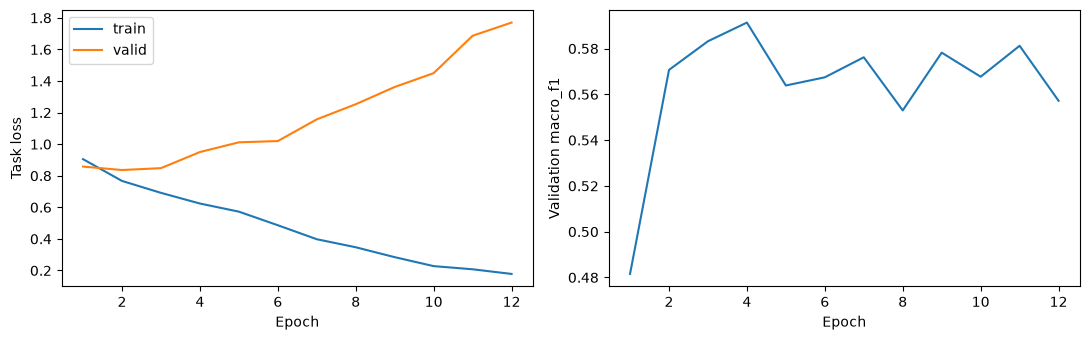

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = mfrm_experiment.history
    epochs = [r["epoch"] for r in history]
    metric = "macro_f1" if mfrm_config.task == "classification" else "mae"
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(epochs, [r["train_loss"] for r in history], label="train")
    axes[0].plot(epochs, [r["valid"]["loss"] for r in history], label="valid")
    axes[0].set(xlabel="Epoch", ylabel="Task loss")
    axes[0].legend()
    axes[1].plot(epochs, [r["valid"][metric] for r in history])
    axes[1].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()

# TransModality 2020：并行双向翻译融合

依据 [论文全文第 3.2–3.3 节及公式 (1)–(7)](https://arxiv.org/pdf/2009.02902) 实现：独立 BiGRU、文本主导的两条正向/返回翻译路径、四路 Transformer encoder 特征与三路上下文特征拼接、分类与四项 MAE 联合训练。

**这是针对现有缓存特征的适配实现，不是原实验的严格复现。** 原文在同一视频的话语序列上建模并逐话语预测；这里输入单个样本的 50 个对齐槽位，以 masked mean 得到一个样本预测。BERT 不参与微调。文本 BiGRU 在两条路径间共享；维度、层数、损失系数、GELU 和 dropout 是本实验设置。

原文明确让 decoder 接收目标模态上下文，但没有明确说明目标移位与因果 mask。本实现使用**未移位的已观测目标序列，非自回归解码**，这些输入在推理时也需要。因此“翻译”是重建辅助学习，不能据此宣称能够仅凭文本生成缺失音频/视频。

若内核已导入旧版 `multimodal_suite`，请先重启内核，然后运行数据加载、原有 mask 设置及本节。


In [1]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.transmodality2020_fusion import (
    Config as TransConfig,
    fit_experiment as fit_trans_experiment,
    explain_feature_groups as explain_trans_features,
    load_experiment_model as load_trans_model,
    predict_split as predict_trans_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先执行已有的数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

## 2. 编码、翻译与分类

```text
text   [B,50,768] → BiGRU → Dense(tanh) → T [B,50,128]
audio  [B,50,74]  → BiGRU → Dense(tanh) → A [B,50,128]
vision [B,50,35]  → BiGRU → Dense(tanh) → V [B,50,128]

文本—音频路径：
T → forward Encoder → E_ta ──┐
A ───────────────→ forward Decoder → D_ta → Linear → audio_hat [B,50,74]
                                      ↓
                                backward Encoder → E_at ──┐
T ─────────────────────────────────────→ backward Decoder → D_at
                                                            ↓ Linear
                                                    text_hat_a [B,50,768]

文本—视觉路径：同样得到 E_tv、E_vt、vision_hat、text_hat_v

concat(E_ta, E_at, E_tv, E_vt, T, A, V) [B,50,896]
                        ↓ masked mean
                  pooled [B,896]
                        ↓ Linear
                    logits [B,3]
```

注意 `E_at` 编码的是前向 decoder 的输出 `D_ta`，不是直接将原音频单独送入另一个 encoder，也不是将 74 维音频重建结果送回。单次推理中的前向 encoder 只读取文本；音视频输入在前向 decoder 和后向 encoder 中参与交互，并通过训练梯度影响前向 encoder。四个 Transformer 参数独立，每个都有 encoder 和 decoder。最终分类拼接的是四路 **encoder** 表示；四路 decoder 表示经各自线性层用于重建，其中前向 decoder 同时连接后向 encoder。

`d_model` 是上下文和 Transformer 宽度，`num_layers` 同时控制 BiGRU 层数及每个 Transformer 的 encoder/decoder 层数，`nhead` 必须整除 `d_model`。位置编码保留原槽位索引；GRU 仅编码有效观测再散回原位置。

仅在源序列有观测且目标槽位有效时重建该目标，跨模态注意力可访问所有有效源槽位，不要求源与目标在同一槽都有效。整条音频缺失时音频路径的 decoder 与后向 encoder 输出为零，前向文本 encoder 仍可产生文本表示；全部模态均缺失的样本拒绝预测。

默认 mask 复用 `text_bert[:,1,:]`，要求三路槽位布局（包括特殊 token 占位）一致；需要独立缺失标记时沿用 `mask_overrides`。全零行不自动判断为缺失。音视频标准化参数只在训练集拟合。

## 3. 联合目标与训练

```text
L_total = L_task
        + λ_ta * MAE(audio_hat, audio_input)
        + λ_at * MAE(text_hat_a, text_input)
        + λ_tv * MAE(vision_hat, vision_input)
        + λ_vt * MAE(text_hat_v, text_input)
```

重建目标是送入模型的特征：音视频启用标准化时，比较的是标准化后的特征，不是波形、像素或文字 token。每项 MAE 对当前批次全部有效目标槽位与特征维度求平均，因此有效槽位较多的样本在该项中占比更高；没有有效目标时该项为 0。最终任务损失则按样本平均。各系数默认 0.1 是本实现的起点，论文没有给出可直接照搬的固定数值。

默认从头联合训练，没有分支冻结或辅助预训练阶段。分类用 CE，验证 Macro-F1 选模；`task="regression"` 使用样本 MAE，并按验证 MAE 选模，这是回归适配。默认最多 40 轮，patience=8，加载最佳模型后统一评估一次测试集。四项重建损失不参与验证选模指标；测试标签不进入模型 forward。若主动设置 `pretrain_epochs>0`，属于额外的辅助预热实验，默认无需启用。



In [2]:
trans_config = TransConfig(
    task="regression",
    d_model=128,
    nhead=4,
    num_layers=1,
    dropout=0.2,
    pretrain_epochs=0,
    model_options={"translation_ff_dim": 256},
    auxiliary_weights={
        "translation_text_audio": 0.1,
        "cycle_audio_text": 0.1,
        "translation_text_vision": 0.1,
        "cycle_vision_text": 0.1,
    },
    epochs=60,
    patience=10,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "transmodality2020_fusion")),
)

trans_experiment = fit_trans_experiment(data, trans_config, mask_overrides=mask_overrides)

model=transmodality2020; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/transmodality2020_fusion/transmodality2020/20260924_225217_494383
Implementation scope: Parallel forward/back translation with four reconstruction losses
supervised_auxiliary_weights={'translation_text_audio': 0.1, 'cycle_audio_text': 0.1, 'translation_text_vision': 0.1, 'cycle_vision_text': 0.1}; pretrain_auxiliary_weights={'translation_text_audio': 0.1, 'cycle_audio_text': 0.1, 'translation_text_vision': 0.1, 'cycle_vision_text': 0.1}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=1.0060 | valid_mae=0.7114
epoch 02 | loss=0.8738 | valid_mae=0.6394
epoch 03 | loss=0.8058 | valid_mae=0.6144
epoch 04 | loss=0.7690 | valid_mae=0.6362
epoch 05 | loss=0.7280 | valid_mae=0.6441
epoch 06 | loss=0.6924 | valid_mae=0.6116
epoch 07 | loss=0.6575 | valid_mae=0.6540
epoch 0

## 4. 检查中间表示与重建误差

`return_intermediates=True` 提供已 detach 的上下文、encoder/decoder 表示、有效 mask、拼接与池化结果。`compute_reconstruction_losses=True` 允许在 eval 模式显式检查重建 MAE；不会启用 dropout 或更新参数。普通推理默认只预测，不计算辅助损失。

下方检查的是一个测试样本，重建误差仅作为结构检查，不用于调整模型或选模。小误差不等于跨模态生成能力，因为 decoder 已接收观测目标上下文。


In [ ]:
print("类别映射:", trans_experiment.class_values)
metrics_record = json.loads((trans_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳轮次:", metrics_record["selected_epoch"])
print("验证集:", trans_experiment.valid_metrics)
print("测试集:", trans_experiment.test_metrics)
print("输出目录:", trans_experiment.run_dir)

item = trans_experiment.datasets["test"][0]
device = next(trans_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
trans_experiment.model.eval()
with torch.no_grad():
    trans_output = trans_experiment.model(
        features, masks, return_intermediates=True, compute_reconstruction_losses=True,
    )

for group in ("unimodal_sequences", "encoder_sequences", "decoder_sequences"):
    print("\n" + group)
    for name, value in trans_output[group].items():
        print(name, tuple(value.shape))
for key in ("concatenated", "fused_sequence", "pooled_features", "logits"):
    print(key, tuple(trans_output[key].shape))
for modality, values in trans_output["reconstructions"].items():
    print(modality, "目标重建:", tuple(values["predicted_beta"].shape),
          "返回文本:", tuple(values["reconstructed_text"].shape),
          "有效目标数:", int(values["forward_mask"].sum()),
          "有效返回文本数:", int(values["backward_mask"].sum()))
print("单样本重建 MAE:", {name: float(loss) for name, loss in trans_output["aux_losses"].items()})


类别映射: [0.0, 1.0, 2.0]
最佳轮次: 2
验证集: {'accuracy': 0.6208791208791209, 'macro_f1': 0.5872015272792156, 'weighted_f1': 0.6117992816947301, 'per_class_f1': [0.6535947712418301, 0.4140127388535032, 0.6939970717423133], 'confusion_matrix': [[150, 22, 34], [45, 65, 74], [58, 43, 237]], 'loss': 0.8567600250244141}
测试集: {'accuracy': 0.6423658872077029, 'macro_f1': 0.5660127286244659, 'weighted_f1': 0.6235769266792415, 'per_class_f1': [0.6709677419354839, 0.28112449799196787, 0.745945945945946], 'confusion_matrix': [[156, 23, 28], [49, 35, 74], [53, 33, 276]], 'loss': 0.7866001725196838}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/transmodality2020_fusion/transmodality2020/20260924_203252_725195

unimodal_sequences
text (1, 50, 128)
audio (1, 50, 128)
vision (1, 50, 128)

encoder_sequences
text_to_audio (1, 50, 128)
audio_to_text (1, 50, 128)
text_to_vision (1, 50, 128)
vision_to_text (1, 50, 128)

decoder_sequences
text_to_audio (1, 50, 128)
audio

## 5. 训练曲线

训练总损失包括加权辅助项，验证损失只有最终任务项，不能直接把两者差值当成过拟合程度。因此第一幅图对照训练/验证 **task loss**，第二幅图记录未乘系数的四项训练 MAE，第三幅图记录验证选模指标。所有原始值和有效系数均保存在输出目录。


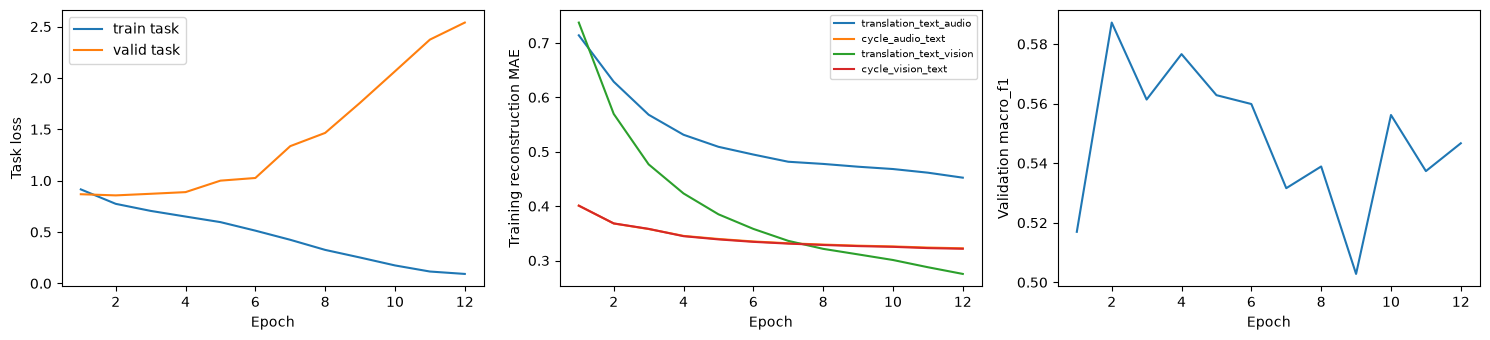

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = [r for r in trans_experiment.history if r["stage"] == "supervised"]
    epochs = [r["epoch"] for r in history]
    metric = "macro_f1" if trans_config.task == "classification" else "mae"
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].plot(epochs, [r["train_task_loss"] for r in history], label="train task")
    axes[0].plot(epochs, [r["valid"]["loss"] for r in history], label="valid task")
    axes[0].set(xlabel="Epoch", ylabel="Task loss")
    axes[0].legend()
    for name in trans_config.auxiliary_weights:
        axes[1].plot(epochs, [r["train"][name] for r in history], label=name)
    axes[1].set(xlabel="Epoch", ylabel="Training reconstruction MAE")
    axes[1].legend(fontsize=7)
    axes[2].plot(epochs, [r["valid"][metric] for r in history])
    axes[2].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


# MEmoBERT 2022 思路适配：条件遮挡重建与联合 Transformer

**本节是 MEmoBERT-inspired 缓存特征基线，不是原论文的预训练模型或硬提示复现。**

参考 [论文方法 §2](https://arxiv.org/pdf/2111.00865) 与 [作者仓库](https://github.com/AIM3-RUC/MEmoBert)。原论文从 BERT token embedding、预训练视觉/声学编码器特征出发，以 BERT 初始化联合骨干，在外部视频数据上进行整词词表预测、音频重建、视觉重建和视觉教师分布 KL 学习；下游使用文字提示 `I am [MASK].`，复用词表预测头。

本节沿用你的 `text[50,768] / audio[50,74] / vision[50,35]`。联合 Transformer 随机初始化，BERT 缓存保持不变；没有加载原 MEmoBERT checkpoint、词表 MLM 头或 FER 教师分布。三路遮挡特征 MSE 替代原预训练任务，三个可学习提示向量和一个查询向量配合新任务头进行预测。它们没有 `I/am/[MASK]` 的词语身份。

缓存 BERT 在遮挡前已经编码了上下文，因此这里的文本重建不是整词 MLM。`text_bert` 在当前数据管线中用于 mask/追溯，不作为新的词嵌入输入。类别编号不自动映射为 happy/sad 等词义。训练集上的短期重建预热也不能替代论文的外部大规模预训练。

若内核已导入旧版 `multimodal_suite`，请先重启内核，再运行数据加载、原有 mask 设置和本节。

In [1]:
import pickle
import os
import json
from pathlib import Path
import torch

from multi_fusion_model.memobert2022_fusion import (
    Config as MemoConfig,
    fit_experiment as fit_memo_experiment,
    explain_feature_groups as explain_memo_features,
    load_experiment_model as load_memo_model,
    predict_split as predict_memo_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None


## 2. 联合序列与预测位置

```text
text   [B,50,768] → 独立 Linear/LayerNorm/GELU/Dropout → [B,50,128]
audio  [B,50,74]  → 独立 Linear/LayerNorm/GELU/Dropout → [B,50,128]
vision [B,50,35]  → 独立 Linear/LayerNorm/GELU/Dropout → [B,50,128]
                         ↓ 各自加位置与模态编码
concat(文本50槽, 音频50槽, 视觉50槽, 3个soft prompt, 1个query)
                         ↓ [B,154,128]
                联合双向 Transformer × 2
                         ↓ LayerNorm
                最后 query 的表示 [B,128]
                         ↓ 新 Linear 任务头
                     logits [B,3]
```

这是**沿序列轴拼接**，不是同一槽位把三路拼成 384 维。各路 50 个槽位仍保留独立位置，联合 self-attention 学习跨模态及跨时间关系。三路共享按原槽位编号索引的位置表，并有不同模态向量；3 个提示向量和 query 自带可学习表示。位置表共享、提示数、投影算子与骨干深度均属于本实现设置，不是照搬论文的完整 BERT。

默认三路观测 mask 复用 `text_bert[:,1,:]`，前提是三路包含特殊 token 占位的布局一致；继续支持 `mask_overrides` 指定各模态缺失。全零行不会自动判为缺失。三模态均无观测的样本拒绝预测。缺失槽位不作为注意力 key/query，而提示位置保持有效。

请区分两种 mask：观测 mask 表示有无数据；预训练 corruption mask 表示暂时遮住哪些**有观测**的特征。被遮特征替换为该模态的可学习 mask 向量，位置和模态编码保留，该位置仍参与注意力。

## 3. 条件遮挡和两阶段训练

每个样本随机选一个有观测的模态进行遮挡，其他两路保持原特征。按 `mask_probability / span_length` 抽取 span 起点，向后扩展最多 `span_length` 个连续有效槽位；遇缺失位置即停止。短样本若未抽中，则遮住所选模态的首个有效位置。因此 `0.15` 是采样参数，不保证恰好遮住 15% 的槽位。这里文本也使用槽位 span，不推断整词边界。

1. **重建预热，默认固定 3 轮：** 仅使用 train 特征，以三项 MSE 的加权和训练；不使用情感标签计算目标，不用 valid/test 特征预热。新任务头不参与该阶段的损失。
2. **任务微调，默认最多 40 轮：** 使用完整观测特征，由最终 query 表示预测样本标签。默认三项重建权重为 0；分类 CE 与验证 Macro-F1 选模，patience=8。选模后评估一次测试集。

每项 MSE 只比较其遮挡位置的原维度输入特征，并对所选槽位和维度平均；未被选中的模态该项为 0。音视频启用标准化时，重建目标也是训练集统计量标准化后的特征。三路各自取均值再求和，避免 768 维文本仅因维度多就获得更大权重。

监督阶段仍记录随机重建诊断，其默认权重为零，不加入任务梯度。可主动提高 `auxiliary_weights` 做联合正则化对照；`pretrain_epochs=0` 可做无重建预热对照。这些都是本适配版实验设置。`task="regression"` 使用 MAE 和一个输出值，是额外的回归适配，不是词表提示分类。



In [2]:
memo_config = MemoConfig(
    task="regression",
    d_model=128,
    nhead=4,
    num_layers=2,
    dropout=0.2,
    pretrain_epochs=3,
    model_options={"memobert_mask_probability": 0.15, "memobert_span_length": 3},
    pretrain_auxiliary_weights={
        "memobert_masked_text": 1.0,
        "memobert_masked_audio": 1.0,
        "memobert_masked_vision": 1.0,
    },
    auxiliary_weights={
        "memobert_masked_text": 0.0,
        "memobert_masked_audio": 0.0,
        "memobert_masked_vision": 0.0,
    },
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "memobert2022_fusion")),
)

memo_experiment = fit_memo_experiment(data, memo_config, mask_overrides=mask_overrides)

model=memobert2022; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/memobert2022_fusion/memobert2022/20260924_225529_862708
Implementation scope: MEmoBERT-inspired cached-feature masking and soft-prompt model
supervised_auxiliary_weights={'memobert_masked_text': 0.0, 'memobert_masked_audio': 0.0, 'memobert_masked_vision': 0.0}; pretrain_auxiliary_weights={'memobert_masked_text': 1.0, 'memobert_masked_audio': 1.0, 'memobert_masked_vision': 1.0}; auxiliary_pretrain_epochs=3
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
pretrain 01 | loss=2.2220
pretrain 02 | loss=1.6161
pretrain 03 | loss=1.4984
epoch 01 | loss=0.7700 | valid_mae=0.6600
epoch 02 | loss=0.6598 | valid_mae=0.6046
epoch 03 | loss=0.5950 | valid_mae=0.6319
epoch 04 | loss=0.5651 | valid_mae=0.6056
epoch 05 | loss=0.5357 | valid_mae=0.6228
epoch 06 | loss=0.5129 | valid_mae=0.6005
epoch 07 | loss=0.4855 | valid_mae=0.

## 4. 检查联合序列与遮挡重建

默认 eval 不采样遮挡，不计算重建损失。`return_intermediates=True` 返回已 detach 的诊断张量。为了单独核查重建，下方固定选择该样本首个有观测模态的最多 3 个连续有效槽位，显式传入 `corruption_masks`；这是确定性诊断，不是训练时的随机采样。

预测 logits 始终来自未额外遮挡的分支。重建由另一次共享参数的 forward 计算，因此诊断遮挡不改变预测。原始缺失仍由观测 mask 控制。诊断样本的重建误差不用于选模。


In [ ]:
print("类别映射:", memo_experiment.class_values)
metrics_record = json.loads((memo_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳微调轮次:", metrics_record["selected_epoch"])
print("验证集:", memo_experiment.valid_metrics)
print("测试集:", memo_experiment.test_metrics)
print("输出目录:", memo_experiment.run_dir)

item = memo_experiment.datasets["test"][0]
device = next(memo_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
memo_experiment.model.eval()
with torch.no_grad():
    memo_output = memo_experiment.model(features, masks, return_intermediates=True)

for group in ("projected_sequences", "embedded_sequences", "unimodal_sequences"):
    for name, value in memo_output[group].items():
        print(group, name, tuple(value.shape))
for key in ("joint_input", "joint_mask", "joint_hidden", "soft_prompt_states",
            "prompt_representation", "pooled_features", "logits"):
    print(key, tuple(memo_output[key].shape))

diagnostic_masks = {m: torch.zeros_like(value) for m, value in masks.items()}
chosen = next(m for m in ("text", "audio", "vision") if masks[m][0].any())
start = int(masks[chosen][0].nonzero(as_tuple=True)[0][0])
for t in range(start, min(start + 3, masks[chosen].shape[1])):
    if not masks[chosen][0, t]:
        break
    diagnostic_masks[chosen][0, t] = True
with torch.no_grad():
    memo_reconstruction = memo_experiment.model(
        features, masks, return_intermediates=True,
        compute_reconstruction_losses=True, corruption_masks=diagnostic_masks,
    )
print("固定遮挡:", chosen, diagnostic_masks[chosen][0].nonzero(as_tuple=True)[0].tolist())
print("重建 MSE:", {name: float(loss) for name, loss in memo_reconstruction["aux_losses"].items()})
print("诊断前后预测最大差异:", float((memo_output["logits"] - memo_reconstruction["logits"]).abs().max()))


类别映射: [0.0, 1.0, 2.0]
最佳微调轮次: 7
验证集: {'accuracy': 0.5975274725274725, 'macro_f1': 0.5933349927617546, 'weighted_f1': 0.6071021744869147, 'per_class_f1': [0.6430379746835443, 0.4856512141280353, 0.6513157894736842], 'confusion_matrix': [[127, 53, 26], [28, 110, 46], [34, 106, 198]], 'loss': 1.2483172416687012}
测试集: {'accuracy': 0.6327372764786795, 'macro_f1': 0.6102890708330894, 'weighted_f1': 0.6419626424324028, 'per_class_f1': [0.7024390243902439, 0.4273972602739726, 0.7010309278350515], 'confusion_matrix': [[144, 35, 28], [29, 78, 51], [30, 94, 238]], 'loss': 1.171558141708374}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/memobert2022_fusion/memobert2022/20260924_204258_360308
projected_sequences text (1, 50, 128)
projected_sequences audio (1, 50, 128)
projected_sequences vision (1, 50, 128)
embedded_sequences text (1, 50, 128)
embedded_sequences audio (1, 50, 128)
embedded_sequences vision (1, 50, 128)
unimodal_sequences text (1, 50, 1

## 5. 分阶段训练曲线

重建预热损失和最终任务损失代表不同目标，分开绘制。第一图是重建预热三项 MSE；第二图对照微调的训练/验证 task loss；第三图是验证选模指标。预热不做验证选模；`pretrained.pt` 保存最后一个预热轮次，`best.pt` 保存验证集选择的微调模型。


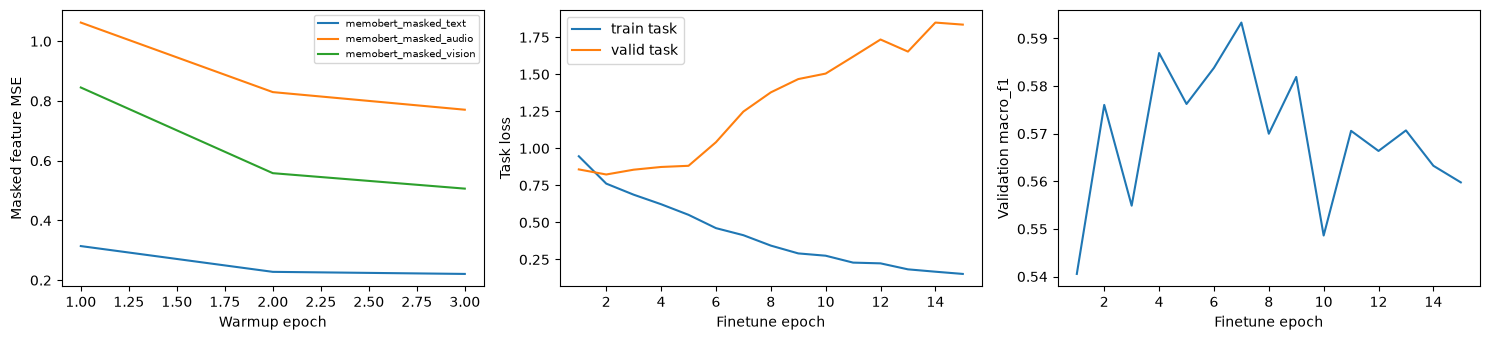

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    warmup = [r for r in memo_experiment.history if r["stage"] == "auxiliary_pretrain"]
    supervised = [r for r in memo_experiment.history if r["stage"] == "supervised"]
    metric = "macro_f1" if memo_config.task == "classification" else "mae"
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    if warmup:
        for name in memo_config.pretrain_auxiliary_weights:
            axes[0].plot([r["epoch"] for r in warmup], [r["train"][name] for r in warmup], label=name)
        axes[0].legend(fontsize=7)
    else:
        axes[0].text(0.5, 0.5, "No reconstruction warmup", ha="center", transform=axes[0].transAxes)
    axes[0].set(xlabel="Warmup epoch", ylabel="Masked feature MSE")
    epochs = [r["epoch"] for r in supervised]
    axes[1].plot(epochs, [r["train_task_loss"] for r in supervised], label="train task")
    axes[1].plot(epochs, [r["valid"]["loss"] for r in supervised], label="valid task")
    axes[1].set(xlabel="Finetune epoch", ylabel="Task loss")
    axes[1].legend()
    axes[2].plot(epochs, [r["valid"][metric] for r in supervised])
    axes[2].set(xlabel="Finetune epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


# HyCon：三模态表征的混合对比学习

**本节依据可核验的 arXiv v1 方法，适配现有缓存特征；不是期刊最终版本的严格复现。**

参考 [原文 §3 与公式 (6)–(14)](https://arxiv.org/pdf/2109.01797v1)。实现独立序列编码、末个有效位置读取、三路向量相加，以及 IAMCL（同模态跨样本）、IEMCL（跨模态跨样本）、SCL（同样本跨模态）三类目标。期刊最终版的配对筛选/加权机制未在本版复现；没有使用作者 checkpoint。

原文语言分支训练 BERT；这里使用已缓存的 BERT 特征，再通过独立 Transformer，BERT 本身不更新。非负 Softplus 投影、三分类 CE、有效锚点取均值、缺失 mask 处理及以下超参数均属于适配设置。原文主要预测连续情感分数，当前默认三分类与前面模型保持一致；也支持 `task="regression"`。

若内核已导入旧版 `multimodal_suite`，请先重启内核，再运行数据加载、原有 mask 设置及本节。


In [1]:
import pickle
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from multi_fusion_model.hycon2022_fusion import (
    Config as HyConConfig,
    fit_experiment as fit_hycon_experiment,
    explain_feature_groups as explain_hycon_features,
    load_experiment_model as load_hycon_model,
    predict_split as predict_hycon_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None


## 2. 三路独立编码与相加融合

```text
text   [B,50,768] → 独立投影 + 位置编码 → text Transformer
                                      → 最后有效槽位 → Linear + Softplus → z_t [B,128]
audio  [B,50,74]  → 独立投影 + 位置编码 → audio Transformer
                                      → 最后有效槽位 → Linear + Softplus → z_a [B,128]
vision [B,50,35]  → 独立投影 + 位置编码 → vision Transformer
                                      → 最后有效槽位 → Linear + Softplus → z_v [B,128]

                              z = z_t + z_a + z_v [B,128]
                                          ↓
                               Linear → ReLU → Linear
                                          ↓
                                     logits [B,3]
```

三路 Transformer 参数独立，不做跨模态注意力；训练时的对比目标让它们在共享维度中学习可融合的表示。每路读取最后一个 **有效槽位**，不是一律读取第 49 槽位；整路缺失时向量为零，相加时不重新按可用模态数平均。所读位置已经包含该模态所有有效位置的双向上下文。

对比支路先对 `z_t/z_a/z_v` 做 L2 归一化，再计算余弦相似度；预测支路相加的是归一化前的向量。Softplus 保证可用向量非负，使相似度满足本实现采用的 `[0,1]` 范围；它是明确的实现选择，因为仅做 L2 归一化本身不能保证非负。

默认观测 mask 来自 `text_bert[:,1,:]`，要求三路槽位布局及特殊 token 占位一致；独立缺失信息继续通过 `mask_overrides` 提供。全零行不自动判缺失，三路均无观测的样本拒绝预测。音视频标准化仅拟合训练集。

## 3. 三类目标与联合训练

| 目标 | 候选配对 | 正对 | 负对 |
| --- | --- | --- | --- |
| IAMCL | 不同样本、相同模态 | 相同类别 | 不同类别 |
| IEMCL | 不同样本、不同模态 | 相同类别 | 不同类别 |
| SCL | 同一样本、不同模态 | 所有可用模态对 | 没有负对 |

SCL 的 semi 指只使用正对，并不是半监督。缺失模态不参加任何配对；IAMCL/IEMCL 排除同一样本，避免与 SCL 重复定义。

设 `s_ij` 为归一化后的相似度，`P_i` 是锚点的正对集合，`C_i` 是对应的所有候选集合。本实现计算：

```text
IAMCL_i = -sum(s_ij, j∈P_i) / sum(s_ij, j∈C_i)
          + refinement_weight * mean((s_ij - 1)^2, j∈P_i)

IEMCL_i = -sum(s_ij, j∈P_i) / sum(s_ij, j∈C_i)
          + refinement_weight * mean((s_ij - margin)^2, j∈P_i)

SCL = mean((s_ij - margin)^2, 同样本跨模态可用对)

L_total = L_task + λ_intra * IAMCL + λ_inter * IEMCL + λ_semi * SCL
```

`margin=0.8` 是跨模态正对的目标相似度，不是下限；高于或低于 0.8 都会产生平方惩罚。同模态正对的修正目标则为 1。

比值前有负号，**没有 log、温度缩放或额外 softmax**。因此 IAMCL/IEMCL 乃至训练总损失可以为负，不能取绝对值或截成零。分母以 `1e-8` 保底；IAMCL/IEMCL 仅对至少有一个正对的锚点取均值，没有可用锚点时返回 0。SCL 对可用有向配对取均值；没有配对时为 0。

这里使用有效锚点/配对均值，原文训练描述使用批次求和，所以默认三个 λ 均为 1 并不代表与论文同等尺度的权重。实际可用对依赖 batch 的类别组成和缺失情况；`batch_size=1` 无法提供跨样本 IAMCL/IEMCL，本例默认 32，采用普通随机打乱而非类别平衡采样。

默认联合训练，不设单独预训练阶段。分类按数据给定的类别索引分组并使用 CE，不自动解释 0/1/2 的情感含义；验证 Macro-F1 选模。回归使用连续标签训练 MAE，但**仅为构造对比配对**约定 `score>=0` 与 `score<0` 两组，零归入前者；这个零值规则是本实现约定。默认最多 40 轮、patience=8，加载最佳模型后统一评估测试集。

标签只参与训练损失中的配对，预测不读取标签或其他样本的特征。普通 eval 不构造对比矩阵。



In [2]:
hycon_config = HyConConfig(
    task="regression",
    d_model=128,
    nhead=4,
    num_layers=1,
    dropout=0.2,
    pretrain_epochs=0,
    model_options={"hycon_margin": 0.8, "hycon_refinement_weight": 1.0},
    auxiliary_weights={"hycon_intra": 1.0, "hycon_inter": 1.0, "hycon_semi": 1.0},
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "hycon2022_fusion")),
)

hycon_experiment = fit_hycon_experiment(data, hycon_config, mask_overrides=mask_overrides)


model=hycon2022; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/hycon2022_fusion/hycon2022/20260924_230010_661690
Implementation scope: HyCon arXiv-v1 hybrid contrastive objectives and additive fusion
supervised_auxiliary_weights={'hycon_intra': 1.0, 'hycon_inter': 1.0, 'hycon_semi': 1.0}; pretrain_auxiliary_weights={'hycon_intra': 1.0, 'hycon_inter': 1.0, 'hycon_semi': 1.0}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=-0.4044 | valid_mae=0.7328
epoch 02 | loss=-0.5169 | valid_mae=0.6116
epoch 03 | loss=-0.5937 | valid_mae=0.6366
epoch 04 | loss=-0.6317 | valid_mae=0.5844
epoch 05 | loss=-0.6655 | valid_mae=0.5975
epoch 06 | loss=-0.6844 | valid_mae=0.6427
epoch 07 | loss=-0.7135 | valid_mae=0.5788
epoch 08 | loss=-0.7391 | valid_mae=0.6104
epoch 09 | loss=-0.7626 | valid_mae=0.6352
epoch 10 | loss=-0.7985 | valid_mae=0.6020
epoch 

## 4. 检查最后有效位置与三路相加

`return_intermediates=True` 返回已 detach 的诊断表示。`last_valid_indices=-1` 表示整路缺失，其表示为零。`modality_representations` 的顺序始终为 text、audio、vision。`pooled_features` 是为兼容现有检查接口保留的名称，其值等于相加后的 `fused_features`，并不是时间均值池化。


In [ ]:
print("类别映射:", hycon_experiment.class_values)
metrics_record = json.loads((hycon_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳轮次:", metrics_record["selected_epoch"])
print("验证集:", hycon_experiment.valid_metrics)
print("测试集:", hycon_experiment.test_metrics)
print("输出目录:", hycon_experiment.run_dir)

item = hycon_experiment.datasets["test"][0]
device = next(hycon_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
hycon_experiment.model.eval()
with torch.no_grad():
    hycon_output = hycon_experiment.model(features, masks, return_intermediates=True)

for m, value in hycon_output["unimodal_sequences"].items():
    print(m, tuple(value.shape), "读取槽位:", int(hycon_output["last_valid_indices"][m][0]))
for key in ("modality_representations", "normalized_representations", "modality_availability",
            "fused_features", "pooled_features", "logits"):
    print(key, tuple(hycon_output[key].shape))
print("三路相加核对最大误差:", float((hycon_output["fused_features"] -
      hycon_output["modality_representations"].sum(1)).abs().max()))


类别映射: [0.0, 1.0, 2.0]
最佳轮次: 2
验证集: {'accuracy': 0.6263736263736264, 'macro_f1': 0.5782603412661217, 'weighted_f1': 0.6102306015600814, 'per_class_f1': [0.6666666666666666, 0.35135135135135137, 0.7167630057803468], 'confusion_matrix': [[156, 21, 29], [55, 52, 77], [51, 39, 248]], 'loss': 0.8336318135261536}
测试集: {'accuracy': 0.6643741403026134, 'macro_f1': 0.5901327370429774, 'weighted_f1': 0.6459643261243864, 'per_class_f1': [0.6943231441048034, 0.312, 0.7640750670241286], 'confusion_matrix': [[159, 20, 28], [48, 39, 71], [44, 33, 285]], 'loss': 0.7745469808578491}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/hycon2022_fusion/hycon2022/20260924_205414_613482
text (1, 50, 128) 读取槽位: 49
audio (1, 50, 128) 读取槽位: 49
vision (1, 50, 128) 读取槽位: 49
modality_representations (1, 3, 128)
normalized_representations (1, 3, 128)
modality_availability (1, 3)
fused_features (1, 128)
pooled_features (1, 128)
logits (1, 3)
三路相加核对最大误差: 0.0


## 5. 用训练小批次检查配对

单个样本不能检查跨样本对比，因此从 **train** 取最多 12 个样本做诊断。显式 `compute_contrastive_losses=True` 允许在 eval 模式检查配对和损失，关闭 dropout、不更新模型；正常测试预测不传标签。

`pair_counts` 统计的是有向对，例如 a→b 和 b→a 计为两对。`usable_anchor_counts` 是拥有至少一个正对的锚点数。可据此发现某个 batch 没有可用的跨样本正对，而不是把零损失误认为已学好。


In [ ]:
train_dataset = hycon_experiment.datasets["train"]
diagnostic_batch = next(iter(DataLoader(train_dataset, batch_size=min(12, len(train_dataset)), shuffle=False)))
pair_features = {m: value.to(device) for m, value in diagnostic_batch["features"].items()}
pair_masks = {m: value.to(device) for m, value in diagnostic_batch["masks"].items()}
pair_targets = diagnostic_batch["target"].to(device)
with torch.no_grad():
    hycon_pairs = hycon_experiment.model(
        pair_features, pair_masks, targets=pair_targets,
        return_intermediates=True, compute_contrastive_losses=True,
    )
print("实际配对标签:", hycon_pairs["contrastive"]["labels"].cpu().tolist())
print("有向配对数:", hycon_pairs["contrastive"]["pair_counts"])
print("有效锚点数:", hycon_pairs["contrastive"]["usable_anchor_counts"])
print("三项对比损失:", {name: float(value) for name, value in hycon_pairs["aux_losses"].items()})


实际配对标签: [2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 0, 2]
有向配对数: {'semi_positives': 72, 'intra_candidates': 396, 'intra_positives': 150, 'intra_negatives': 246, 'inter_candidates': 792, 'inter_positives': 300, 'inter_negatives': 492}
有效锚点数: {'intra': 36, 'inter': 36}
三项对比损失: {'hycon_semi': 0.0016832450637593865, 'hycon_intra': -0.40557411313056946, 'hycon_inter': -0.38049039244651794}


## 6. 训练曲线

训练总损失包含可为负的对比项，而验证损失仅为最终任务损失。因此分别画任务损失、三项对比目标和验证指标；不要把训练总损失与验证任务损失的差值当成过拟合程度。完整总损失仍记录在 `history.json` 中。


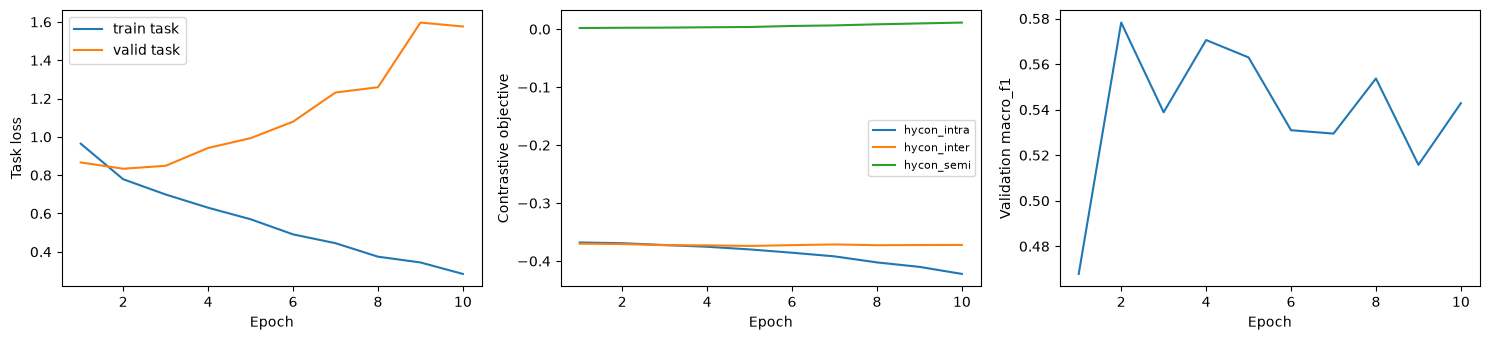

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = hycon_experiment.history
    epochs = [r["epoch"] for r in history]
    metric = "macro_f1" if hycon_config.task == "classification" else "mae"
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].plot(epochs, [r["train_task_loss"] for r in history], label="train task")
    axes[0].plot(epochs, [r["valid"]["loss"] for r in history], label="valid task")
    axes[0].set(xlabel="Epoch", ylabel="Task loss")
    axes[0].legend()
    for name in hycon_config.auxiliary_weights:
        axes[1].plot(epochs, [r["train"][name] for r in history], label=name)
    axes[1].set(xlabel="Epoch", ylabel="Contrastive objective")
    axes[1].legend(fontsize=8)
    axes[2].plot(epochs, [r["valid"][metric] for r in history])
    axes[2].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


# EMOE：动态模态专家与在线单模态特征蒸馏

**本节是经过官方代码核查的缓存特征适配，保留三模态密集路由、加权求和、单模态监督及在线特征蒸馏。**

来源：[CVPR 2025 论文与补充材料](https://openaccess.thecvf.com/content/CVPR2025/html/Fang_EMOE_Modality-Specific_Enhanced_Dynamic_Emotion_Experts_CVPR_2025_paper.html)、[官方代码固定版本 c4759c748105e18354cd9082b1d8c6d310f1f9d8](https://github.com/fuyyyyy/EMOE/tree/c4759c748105e18354cd9082b1d8c6d310f1f9d8)。官方补充代码与该版本的核心模型、路由、训练和损失文件已对照；实验配置会保存来源及适配范围。

这里沿用你已有的 text/audio/vision 特征，BERT 本身不更新；默认三分类，也支持 `task="regression"`。保留原始特征展平后输入路由器，但把其隐藏宽度从原代码的 `输入维度//8` 调整为 128：当前 `50×(768+74+35)=43850`，原设置第一层约有 2.4 亿权重，本设置约 561 万权重。

为保留槽位索引，输入投影使用核为 1 的逐位置线性变换，采用显式观测 mask、最后有效位置读取及双向 Transformer；原代码使用时序卷积、固定最后位置和默认因果注意力。这些改动、缓存 BERT、三分类 CE 与 Brier 重要性误差、模型宽度及训练超参数都是本次适配，不是作者 checkpoint 的兼容复现。

若内核已导入旧版 `multimodal_suite`，先重启内核，再运行数据加载、原有 mask 设置及本节。


In [1]:
import pickle
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from multi_fusion_model.emoe2025_fusion import (
    Config as EMOEConfig,
    fit_experiment as fit_emoe_experiment,
    explain_feature_groups as explain_emoe_features,
    load_experiment_model as load_emoe_model,
    predict_split as predict_emoe_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None


## 2. 先得到样本级模态权重，再融合专家表示

```text
text   [B,50,768] ─ 独立投影 ─┐                      ┌ text Transformer   → h_t [B,128]
audio  [B,50,74]  ─ 独立投影 ─┼ 共享 Linear(128,128) ┼ audio Transformer  → h_a [B,128]
vision [B,50,35]  ─ 独立投影 ─┘   + 正弦位置编码     └ vision Transformer → h_v [B,128]
                                                    每路取最后有效槽位

三路输入先按 mask 清零 → 每槽位拼接 [B,50,877] → 展平 [B,43850]
    → Linear(43850,128) → L2 normalize → ReLU → Linear(128,3)
    → 除以 temperature=0.1 → 可用模态上 softmax → w [B,3]

fused = w_t*h_t + w_a*h_a + w_v*h_v [B,128]
    → 融合残差 MLP → r_f [B,128] → Linear → logits [B,3]

每路 h_m → 各自残差 MLP → r_m [B,128] → Linear → 单模态 logits [B,3]
```

残差 MLP 为 `r = h + Linear(Dropout(ReLU(Linear(h))))`。三个专家分别是文本、音频和视觉分支；权重是每条样本的三个数，使用密集 softmax，没有 top-k 或路由噪声。权重只在序列表征完成后参与融合，三路 Transformer 参数独立，前面的共享 Linear 使用同一组参数。

本实现的模态顺序固定为 **text、audio、vision（T/A/V）**，与官方代码的 T/V/A 顺序不同。整路缺失时其表示、单模态输出及路由权重均为零，其他可用模态权重重新归一化；三路全缺失则拒绝输入。短于最大长度的输入仅为固定宽度路由右侧补零，不改变已有槽位索引。

默认 mask 来自 `text_bert[:,1,:]`，要求三路槽位布局及特殊 token 占位一致；独立缺失信息通过 `mask_overrides` 提供。全零行不自动判缺失。音视频标准化参数仅拟合训练集；图中的输入指进入模型的特征，音视频按配置已标准化。


## 3. 四项辅助目标与联合训练

对每条样本，设可用模态集合为 `A`，数量为 `n_available`。默认总目标为：

```text
L_total = L_fused_task
        + 1.00 * L_unimodal
        + 0.01 * L_router_fit
        + 0.10 * L_router_entropy
        + 0.10 * L_distillation
```

| 辅助目标 | 当前计算方式 |
| --- | --- |
| `emoe_unimodal` | 每个样本的可用单模态任务损失取均值，再对 batch 取均值；分类用 CE，回归用 MAE |
| `emoe_router_fit` | 每路可靠性 `q_m=1/(error_m+0.1)`；在可用模态中归一化得到 `I=stop_gradient(q/sum(q))`，计算 `w` 与 `I` 的可用模态均方差，再取 batch 均值 |
| `emoe_router_entropy` | `mean_batch[n_available * sum_m(w_m * log(clamp_min(w_m,1e-9)))]`，缺失模态权重为零 |
| `emoe_distillation` | 融合残差特征 `r_f` 与目标 `stop_gradient(sum_m w_m*r_m)`，分别沿特征维 softmax，再对 batch 和特征维做 MSE |

三分类重要性误差是 Brier 形式：`error_m=mean_class((softmax(unimodal_logits_m)-one_hot(y))^2)`；回归误差是 `(prediction_m-y)^2`。三分类可靠性规则是本次扩展，不把类别编号当作连续情感分数。类别 0/1/2 的情感含义仍由你的数据定义。

负熵项鼓励路由保留多模态的学习机会，防止一开始完全集中于单一路；不是要求每个样本的最终权重均匀。**它可以为负，总训练损失也可以为负**。有三路观测时 `n_available=3`，恢复作者代码中的专家数系数；缺失时按实际可用数量调整。

蒸馏目标来自同一模型当前的单模态残差特征，整个加权目标（包括其中的路由权重）停止梯度。单模态分支通过各自任务监督继续训练；蒸馏的 student 是融合残差特征。共享上游参数仍可通过融合路径得到梯度。这里没有另一个冻结的预训练教师，也不设预训练阶段；四项辅助目标从第一轮与融合任务共同训练。`temperature=0.1` 仅用于路由，蒸馏没有额外温度，也不是类别概率 KL。

论文公式将重要性写成倒数误差后 softmax，发布代码实际使用倒数误差除和；本节采用发布代码。论文蒸馏部分的 logits 与方向措辞也存在歧义，本节按实际梯度路径执行隐藏特征 softmax-MSE：融合分支学习停止梯度的单模态组合目标。

标签只用于训练任务和可靠性目标，不进入路由或预测。普通 eval 的辅助损失为空。默认三分类用验证 Macro-F1 选模；回归用验证 MAE。最多 40 轮、patience=8，最后加载验证最佳模型评估测试集。


In [2]:
emoe_config = EMOEConfig(
    task="regression",
    d_model=128,
    nhead=4,
    num_layers=2,
    dropout=0.2,
    pretrain_epochs=0,
    model_options={
        "emoe_router_hidden": 128,
        "emoe_temperature": 0.1,
        "emoe_reliability_epsilon": 0.1,
    },
    auxiliary_weights={
        "emoe_unimodal": 1.0,
        "emoe_router_fit": 0.01,
        "emoe_router_entropy": 0.1,
        "emoe_distillation": 0.1,
    },
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "emoe2025_fusion")),
)

emoe_experiment = fit_emoe_experiment(data, emoe_config, mask_overrides=mask_overrides)


model=emoe2025; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/emoe2025_fusion/emoe2025/20260924_230154_459002
Implementation scope: EMOE code-based dense modality routing and online unimodal feature distillation
supervised_auxiliary_weights={'emoe_unimodal': 1.0, 'emoe_router_fit': 0.01, 'emoe_router_entropy': 0.1, 'emoe_distillation': 0.1}; pretrain_auxiliary_weights={'emoe_unimodal': 1.0, 'emoe_router_fit': 0.01, 'emoe_router_entropy': 0.1, 'emoe_distillation': 0.1}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=1.3131 | valid_mae=0.7539
epoch 02 | loss=1.1054 | valid_mae=0.6450
epoch 03 | loss=0.9885 | valid_mae=0.6381
epoch 04 | loss=0.9087 | valid_mae=0.6550
epoch 05 | loss=0.8650 | valid_mae=0.6443
epoch 06 | loss=0.8087 | valid_mae=0.6293
epoch 07 | loss=0.7613 | valid_mae=0.6544
epoch 08 | loss=0.7259 | valid_mae=0.6854
epoc

## 4. 查看形状、最后有效位置与路由表

在 `eval()` 与 `torch.no_grad()` 下检查第一个测试样本，不传标签、不更新模型。`last_valid_indices=-1` 表示整路缺失。`expert_representations`、`modality_logits` 和 `routing_weights` 的模态轴顺序均为 T/A/V。

`fused_features` 是加权求和后的向量；`fusion_residual_features` 是融合预测头中的残差向量。兼容字段 `pooled_features` 等于后者，不是时间均值池化。


In [ ]:
print("类别映射:", emoe_experiment.class_values)
metrics_record = json.loads((emoe_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳轮次:", metrics_record["selected_epoch"])
print("验证集:", emoe_experiment.valid_metrics)
print("测试集:", emoe_experiment.test_metrics)
print("输出目录:", emoe_experiment.run_dir)

item = emoe_experiment.datasets["test"][0]
device = next(emoe_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
emoe_experiment.model.eval()
with torch.no_grad():
    emoe_output = emoe_experiment.model(features, masks, return_intermediates=True)

for m, value in emoe_output["unimodal_sequences"].items():
    print(m, tuple(value.shape), "读取槽位:", int(emoe_output["last_valid_indices"][m][0]))
for key in ("router_features", "router_hidden", "routing_weights", "expert_representations",
            "unimodal_residual_features", "modality_logits", "modality_availability",
            "fused_features", "fusion_residual_features", "pooled_features", "logits"):
    print(key, tuple(emoe_output[key].shape))
print("加权求和最大误差:", float((emoe_output["fused_features"] -
      (emoe_output["routing_weights"][..., None] * emoe_output["expert_representations"]).sum(1)).abs().max()))
print("普通 eval 辅助损失:", emoe_output["aux_losses"])

emoe_routing_rows = []
for j, m in enumerate(("text", "audio", "vision")):
    observed = bool(emoe_output["modality_availability"][0, j])
    raw_prediction = emoe_output["modality_logits"][0, j].cpu()
    if not observed:
        prediction = None
    elif emoe_config.task == "classification":
        prediction = emoe_experiment.class_values[int(raw_prediction.argmax())]
    else:
        prediction = float(raw_prediction[0])
    emoe_routing_rows.append({
        "modality": m, "observed": observed,
        "routing_weight": float(emoe_output["routing_weights"][0, j]),
        "unimodal_prediction": prediction,
    })
try:
    import pandas as pd
except ImportError:
    for row in emoe_routing_rows:
        print(row)
else:
    print(pd.DataFrame(emoe_routing_rows).to_string(index=False))
print("路由权重之和:", float(emoe_output["routing_weights"][0].sum()))


类别映射: [0.0, 1.0, 2.0]
最佳轮次: 3
验证集: {'accuracy': 0.5961538461538461, 'macro_f1': 0.5657315611715976, 'weighted_f1': 0.5906884174010344, 'per_class_f1': [0.5828877005347594, 0.43304843304843305, 0.6812585499316005], 'confusion_matrix': [[109, 35, 62], [26, 76, 82], [33, 56, 249]], 'loss': 1.2287949323654175}
测试集: {'accuracy': 0.6217331499312242, 'macro_f1': 0.5595143504985218, 'weighted_f1': 0.6098974560708263, 'per_class_f1': [0.6240409207161125, 0.33093525179856115, 0.7235668789808917], 'confusion_matrix': [[122, 31, 54], [27, 46, 85], [35, 43, 284]], 'loss': 1.15486478805542}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/emoe2025_fusion/emoe2025/20260924_213511_167629
text (1, 50, 128) 读取槽位: 49
audio (1, 50, 128) 读取槽位: 49
vision (1, 50, 128) 读取槽位: 49
router_features (1, 43850)
router_hidden (1, 128)
routing_weights (1, 3)
expert_representations (1, 3, 128)
unimodal_residual_features (1, 3, 128)
modality_logits (1, 3, 3)
modality_availabil

路由表说明模型如何混合当前样本的三路表示。权重不是准确率、解释置信度或最终分数的贡献比例；即使视觉权重较大，也不能直接认定某一帧决定了预测。下一步可以用完整模型的槽位替换检查预测敏感性。

## 5. 在训练小批次上检查四项辅助损失

从 **train** 取最多 12 个样本，在 eval 模式显式启用 `compute_auxiliary_losses=True`。这一检查关闭 dropout、不反向传播，标签仅用于展示训练可靠性目标和单模态任务损失；不会拿测试标签调整路由。辅助目标开关不改变预测路径。


In [ ]:
train_dataset = emoe_experiment.datasets["train"]
diagnostic_batch = next(iter(DataLoader(train_dataset, batch_size=min(12, len(train_dataset)), shuffle=False)))
diagnostic_features = {m: value.to(device) for m, value in diagnostic_batch["features"].items()}
diagnostic_masks = {m: value.to(device) for m, value in diagnostic_batch["masks"].items()}
diagnostic_targets = diagnostic_batch["target"].to(device)
with torch.no_grad():
    emoe_plain = emoe_experiment.model(diagnostic_features, diagnostic_masks)
    emoe_diagnostics = emoe_experiment.model(
        diagnostic_features, diagnostic_masks, targets=diagnostic_targets,
        return_intermediates=True, compute_auxiliary_losses=True,
    )
print("四项原始辅助损失:", {name: float(value) for name, value in emoe_diagnostics["aux_losses"].items()})
print("辅助诊断前后 logits 最大误差:", float((emoe_plain["logits"] - emoe_diagnostics["logits"]).abs().max()))
print("训练样本 0 的可用模态 T/A/V:", emoe_diagnostics["modality_availability"][0].cpu().tolist())
print("训练样本 0 的可靠性误差 T/A/V:", emoe_diagnostics["routing_errors"][0].cpu().tolist())
print("训练样本 0 的路由权重 T/A/V:", emoe_diagnostics["routing_weights"][0].cpu().tolist())
print("训练样本 0 的可靠性目标 T/A/V:", emoe_diagnostics["importance_targets"][0].cpu().tolist())
print("在线蒸馏目标形状:", tuple(emoe_diagnostics["distillation_target"].shape))


四项原始辅助损失: {'emoe_distillation': 1.6584403056185693e-05, 'emoe_router_entropy': -3.02296781539917, 'emoe_unimodal': 0.8399286270141602, 'emoe_router_fit': 0.02324962615966797}
辅助诊断前后 logits 最大误差: 0.0
训练样本 0 的可用模态 T/A/V: [True, True, True]
训练样本 0 的可靠性误差 T/A/V: [0.0012603466166183352, 0.11221995204687119, 0.11022740602493286]
训练样本 0 的路由权重 T/A/V: [0.3964589238166809, 0.18878120183944702, 0.41475990414619446]
训练样本 0 的可靠性目标 T/A/V: [0.5105118155479431, 0.24358974397182465, 0.24589850008487701]
在线蒸馏目标形状: (12, 128)


## 6. 分开查看任务损失与辅助目标

训练总损失包含单模态、路由和蒸馏目标，验证损失仅为最终融合任务损失。下面分别画融合任务损失、四项未经系数缩放的辅助目标，以及验证指标；负熵使总损失可能为负，因此不把训练总损失和验证任务损失直接作差。完整总损失保存在 `history.json`。


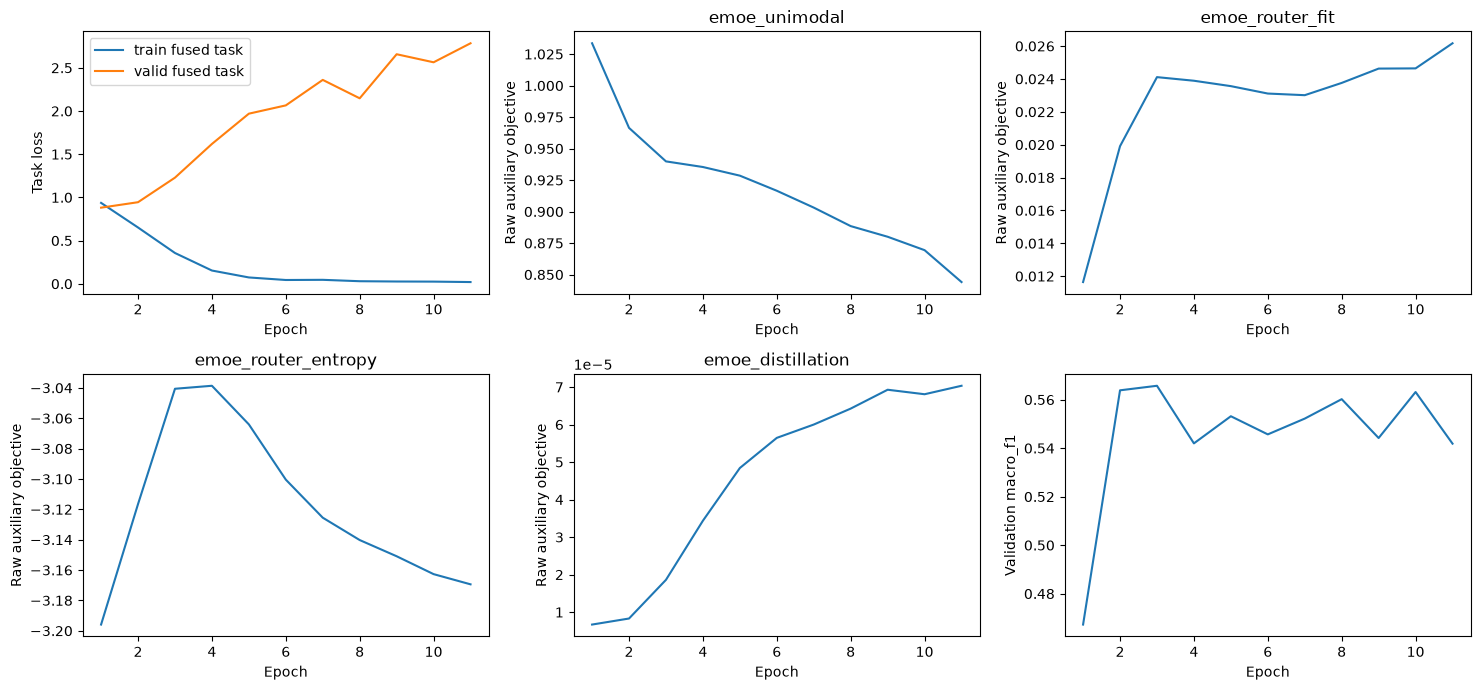

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = emoe_experiment.history
    epochs = [r["epoch"] for r in history]
    metric = "macro_f1" if emoe_config.task == "classification" else "mae"
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes = axes.ravel()
    axes[0].plot(epochs, [r["train_task_loss"] for r in history], label="train fused task")
    axes[0].plot(epochs, [r["valid"]["loss"] for r in history], label="valid fused task")
    axes[0].set(xlabel="Epoch", ylabel="Task loss")
    axes[0].legend()
    for axis, name in zip(axes[1:5], emoe_config.auxiliary_weights):
        axis.plot(epochs, [r["train"][name] for r in history])
        axis.set(xlabel="Epoch", ylabel="Raw auxiliary objective", title=name)
    axes[5].plot(epochs, [r["valid"][metric] for r in history])
    axes[5].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


## 7. 槽位追溯、保存的路由与模型重载

输出目录保存来源与配置、训练集标准化参数、mask 审计、训练历史、最佳模型和验证/测试指标。预测 NPZ 同时保存样本 ID、最终 logits、`routing_weights [N,3]`、`modality_logits [N,3,C]` 与 `modality_availability [N,3]`，顺序都是 T/A/V；回归时 `C=1`。`predict_split` 重载预测也返回这些字段。

解释接口固定 mask 和目标/参照类别，替换某个模态某个槽位的缓存特征，再运行整个模型。因此它同时包含专家表示变化与路由重新加权，而非固定路由下的孤立影响。返回结果是特征替换后的预测敏感性，不是因果贡献；可通过 `id + modality + time_index` 关联原始词时间戳、音频和帧号。缓存 BERT 会把词的信息分散到其他上下文槽位中，原始词删除需要重新提取特征才能检验。


In [ ]:
emoe_explanation = explain_emoe_features(emoe_experiment, split="test", index=0)
print("解释是否包含路由重新加权:", emoe_explanation["includes_router_reweighting"])
for row in emoe_explanation["rows"][:15]:
    print(row)

emoe_model, emoe_metadata = load_emoe_model(emoe_experiment.run_dir / "best.pt")
one_sample = {key: value[:1] for key, value in data["test"].items()}
one_sample_masks = {
    m: value[:1] for m, value in (mask_overrides or {}).get("test", {}).items()
} or None
emoe_prediction = predict_emoe_split(emoe_model, one_sample, emoe_metadata, masks=one_sample_masks)
print("重载后的 logits:", emoe_prediction["logits"])
print("重载后的路由 T/A/V:", emoe_prediction["routing_weights"])
print("重载后的可用模态 T/A/V:", emoe_prediction["modality_availability"])


解释是否包含路由重新加权: True
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 49, 'modality': 'text', 'aligned_text_token_id': 102, 'score_drop': 1.0251505374908447, 'original_score': 4.653486728668213, 'perturbed_score': 3.628336191177368}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 49, 'modality': 'audio', 'aligned_text_token_id': 102, 'score_drop': -0.4008817672729492, 'original_score': 4.653486728668213, 'perturbed_score': 5.054368495941162}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 48, 'modality': 'text', 'aligned_text_token_id': 16308, 'score_drop': 0.368438720703125, 'original_score': 4.653486728668213, 'perturbed_score': 4.285048007965088}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 42, 'modality': 'audio', 'aligned_text_token_id': 6387, 'score_drop': -0.33681154251098633, 'original_score': 4.653486728668213, 'perturbed_score': 4.990298271179199}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 28, 'modality': 'text', 'aligned_text_token_id': 3676, 'score_drop': -0.28145837783813477, 'original_score': 4.65348672866

# CaReFlow：循环自适应整流流与多模态融合

**本节在你的缓存序列特征上实现 CaReFlow 的模态分布映射、自适应流匹配和反向循环约束。**

来源：[CVPR 2026 最终论文](https://openaccess.thecvf.com/content/CVPR2026/papers/Mai_CaReFlow_Cyclic_Adaptive_Rectified_Flow_for_Multimodal_Fusion_CVPR_2026_paper.pdf)、[补充材料](https://openaccess.thecvf.com/content/CVPR2026/supplemental/Mai_CaReFlow_Cyclic_Adaptive_CVPR_2026_supplemental.pdf)、[早期公开稿](https://arxiv.org/html/2602.19140v1)、[官方代码固定版本 5c9f9c7a0bb3f1202ebb3258052da2b99710c565](https://github.com/TmacMai/CaReFlow/tree/5c9f9c7a0bb3f1202ebb3258052da2b99710c565)。本节已核查作者发布代码，流匹配、Euler 梯度和循环起点按该版本实现；是缓存特征适配，不是作者 checkpoint 的兼容复现。

输入仍为 `text [N,50,768]`、`audio [N,50,74]`、`vision [N,50,35]`。原实现微调 DeBERTa，本节直接使用已有 BERT 缓存，不更新文本编码器；音视频用卷积和独立 Transformer 编码。默认三分类，也支持回归。模型宽度、层数、mask、池化和监督任务均按当前数据做了适配。

这里的“对齐”是**样本级表示空间的变换**。已有 50 个对应槽位的时间对齐关系仍由数据提供；流时间 `t∈[0,1]` 是数值积分参数，不是词序号、视频秒数或音频时间戳。循环目标帮助保留原模态表示信息，不是缺失音视频片段的补全器。

若内核已导入旧版 `multimodal_suite`，先重启内核，再运行数据加载、原有 mask 设置及本节。

In [1]:
import pickle
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from multi_fusion_model.careflow2026_fusion import (
    Config as CaReFlowConfig,
    fit_experiment as fit_careflow_experiment,
    explain_feature_groups as explain_careflow_features,
    load_experiment_model as load_careflow_model,
    predict_split as predict_careflow_split,
    audit_data,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None


## 2. 单模态编码 → 样本级流映射 → 拼接预测

```text
text   [B,50,768] → Linear ────────────────────→ LayerNorm → masked mean → h_t [B,128]
audio  [B,50,74]  → Conv1d(k=3,p=1) → Transformer → LayerNorm → masked mean → h_a [B,128]
vision [B,50,35]  → Conv1d(k=3,p=1) → Transformer → LayerNorm → masked mean → h_v [B,128]

h_a → 前向速度场 V_a(z,t) → 2 步 Euler 积分 → mapped_a [B,128]
h_v → 前向速度场 V_v(z,t) → 2 步 Euler 积分 → mapped_v [B,128]

concat(h_t, mapped_a, mapped_v) [B,384]
  → Linear(384,128) → ReLU → Linear(128,128) → fused [B,128]
  → Linear(128,128) → ReLU → Linear(128,3) → logits [B,3]
```

速度场接收 `concat(z, sinusoidal_time_embedding(t)) [B,256]`，通过四层 Linear：`256→128→128→128→128`，前三层后接 ReLU。音频、视觉各有前向与反向速度场，共四套参数；时间嵌入使用 `1000*t`。`num_layers` 与 `nhead` 控制音视频 Transformer。

预测路径从实际模态表示开始，不从随机高斯噪声开始。设置 `K=careflow_steps` 后，`dt=1/K`，每步 `z ← z + dt*V(z,t)`；默认 `K=2`，可检查 `t=0、0.5、1` 的三个状态。训练中的实现按发布代码计算 `V(stop_gradient(z),t)`，残差路径中的 `z` 保留梯度，所以主任务仍能训练原始表示和各步速度参数，但不经速度网络对状态的 Jacobian 跨步回传。

前向速度场在训练中学习语言空间的分布关系，**预测当前样本时只使用该模态自己的表示，不需要取另一条样本或真实标签来设终点**。文本表示仍作为独立一路参与最终融合。

本实现对音视频 Transformer 使用位置编码及显式观测 mask，三路采用 masked mean；发布代码默认不屏蔽所有 padding。无观测槽位在进入卷积前清零、各层后再次屏蔽，整路缺失的池化和流映射结果保持零；三路全缺失则拒绝输入。卷积会混合相邻有效槽位的信息，因此单个槽位的变化也可能影响邻近序列表征。

默认 mask 来自 `text_bert[:,1,:]`，要求三路槽位和特殊 token 的占位一致；独立缺失信息使用 `mask_overrides`。全零特征行不自动视为缺失。音视频标准化参数仅由训练集拟合。


## 3. 自适应松弛与循环约束

设 `x0` 为某个音频／视觉表示，`x1` 为文本表示。训练时抽取 `t∼Uniform(0,1)`，构造直线路径 `x_t=(1-t)*x0+t*x1`，让速度场预测 `x1-x0`：

```text
error = mean_feature((V(x_t,t) - (x1-x0))**2)
L_forward = mean_pair(max(error - margin, 0))
```

每路先加入全部“本样本源模态 → 本样本文本”的有效配对。然后按 `careflow_pair_ratio × 同样本有效对数` 的数量，从本 batch 的可观测源模态和文本中独立、有放回地抽取两端索引，再过滤源和目标同属一条样本的提案，不补抽。实际跨样本对数因此可能少于该倍率；没有有效配对时跳过。`pair_ratio=4` 是配对提案数量的倍率，不是流步数或损失系数；设为 0 可只保留同样本配对。

| 配对 | margin |
| --- | --- |
| 同一样本 | 0，保持严格配对 |
| 不同样本、同类别 | `careflow_margin`，默认 `1e-4` |
| 不同样本、不同类别 | `careflow_margin + 1` |
| 回归任务中的不同样本 | `careflow_margin + (y_i-y_j)**2` |

分类采用论文所述的“类别是否相同”定义距离；不会用类别编号 0/1/2 的数值差假装情感强度。松弛仅意味着误差小于阈值时不继续惩罚，并非把不同类别直接变成相同语义。

前向流匹配中，文本目标 `x1` 停止梯度，源模态 `x0` 保留梯度。循环起点按发布代码采用每个同样本配对的**随机时刻一步估计**：`cycle_start = stop_gradient(x0) + V(x_t,t)`；它与预测用的两步 Euler 终点不同。反向流以 `cycle_start` 为起点，以 `stop_gradient(x0)` 为目标，再抽取随机时间，学习恢复方向的速度。`cycle_start` 不 detach，所以反向目标能够约束前向速度网络及其上游源分支；反向损失使用特征维 MSE，不设松弛 margin。

反向 Euler 恢复仅用于诊断，从确定性的前向 Euler 终点开始运行；训练中的循环约束仍是上述随机起点的反向速度匹配，不额外叠加端点重构 MSE。

默认联合目标：

```text
L_total = L_task
        + 0.1 * L_forward_audio + 0.1 * L_forward_vision
        + 0.1 * L_backward_audio + 0.1 * L_backward_vision
```

每项流损失先对特征维取平均，再在该路有效配对上取平均。某路没有有效配对时该项为可反传的零；反向循环仅使用源模态和文本均有观测的同样本配对。缺失文本时，已观测音视频仍可运行确定性流映射参与预测。普通 eval 不抽配对、不抽随机时间，辅助损失为空，预测不依赖标签或同 batch 的其他样本。

**公式与代码的对应：**论文写平方 L2 范数，发布代码对特征维取均值；本节按发布代码处理。Euler 的状态 detach、随机时刻一步循环起点和 `sin` 块后接 `cos` 块的时间嵌入排列，也采用发布代码，而不是根据概念描述另写一套流模型。缓存 BERT 替代 DeBERTa 微调、显式 mask 与 masked mean、缺失分支处理、分类 CE／回归 MAE、模型宽度及默认损失系数均是当前实验适配，不能把结果直接当作作者官方基线分数。

早期 arXiv v1 在公式 10 后写过前向流匹配不更新单模态编码器；CVF 最终稿已删除这句。当前固定版本代码只 detach 文本目标，保留音视频源端梯度，本节与该实现一致。

默认 `pair_ratio=4`、Euler 步数 2、前后向系数各 0.1、`margin=1e-4` 取自补充材料的 MOSI 设置，作为当前实验的起点。补充材料该设置的共享宽度为 120，本节统一为 128；监督损失由论文 MSE 改为分类 CE／回归 MAE，优化器及训练设置也沿用当前项目，因此这组参数不代表已经在你的数据上调优。

默认不预训练，四项辅助目标从第一轮加入。最多 40 轮、patience=8，用验证 Macro-F1（回归用 MAE）选模，加载验证最佳模型后评估测试集。


In [2]:
careflow_config = CaReFlowConfig(
    task="regression",
    d_model=128,
    nhead=4,
    num_layers=1,
    dropout=0.2,
    pretrain_epochs=0,
    model_options={
        "careflow_steps": 2,
        "careflow_pair_ratio": 4,
        "careflow_margin": 1e-4,
        "careflow_fusion_hidden": 128,
    },
    auxiliary_weights={
        "careflow_forward_audio": 0.1,
        "careflow_forward_vision": 0.1,
        "careflow_backward_audio": 0.1,
        "careflow_backward_vision": 0.1,
    },
    epochs=40,
    patience=8,
    batch_size=32,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    standardize_av=True,
    class_weighted_loss=False,
    device=None,
    output_root=str(os.path.join(MODULE_DIR, "careflow2026_fusion")),
)

careflow_experiment = fit_careflow_experiment(data, careflow_config, mask_overrides=mask_overrides)


model=careflow2026; device=cuda; output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/careflow2026_fusion/careflow2026/20260924_230527_038398
Implementation scope: CaReFlow relaxed rectified-flow matching and cyclic information preservation
supervised_auxiliary_weights={'careflow_forward_audio': 0.1, 'careflow_forward_vision': 0.1, 'careflow_backward_audio': 0.1, 'careflow_backward_vision': 0.1}; pretrain_auxiliary_weights={'careflow_forward_audio': 0.1, 'careflow_forward_vision': 0.1, 'careflow_backward_audio': 0.1, 'careflow_backward_vision': 0.1}; auxiliary_pretrain_epochs=0
Aligned cached features; shared text mask unless overridden. Zero rows do not imply missingness.
epoch 01 | loss=0.7988 | valid_mae=0.6705
epoch 02 | loss=0.6664 | valid_mae=0.6095
epoch 03 | loss=0.6170 | valid_mae=0.5889
epoch 04 | loss=0.5819 | valid_mae=0.6313
epoch 05 | loss=0.5629 | valid_mae=0.6305
epoch 06 | loss=0.5562 | valid_mae=0.6042
epoch 07 | loss=0.5325 | 

## 4. 查看样本级表示和流轨迹

以下用第一个测试样本，只检查确定性预测路径，不传标签、不计算训练配对。`pooled_modalities` 是各路进入流之前的向量，`mapped_modalities` 是变换后的向量（文本保持原样）；`concatenated` 按 **text、audio、vision** 拼接。`pooled_features` 兼容字段等于融合 MLP 的输出 `fused_features`。

`forward_trajectories[m] [B,K+1,d]` 包含起点和每次 Euler 更新后的状态，沿第二维查看的是特征空间演化，而非原始 50 个时间槽位。反向轨迹是附加检查，不参与普通预测；未训练好时不应预期完全恢复原表示。


In [ ]:
print("类别映射:", careflow_experiment.class_values)
metrics_record = json.loads((careflow_experiment.run_dir / "metrics.json").read_text(encoding="utf-8"))
print("最佳轮次:", metrics_record["selected_epoch"])
print("验证集:", careflow_experiment.valid_metrics)
print("测试集:", careflow_experiment.test_metrics)
print("输出目录:", careflow_experiment.run_dir)

item = careflow_experiment.datasets["test"][0]
device = next(careflow_experiment.model.parameters()).device
features = {m: value.unsqueeze(0).to(device) for m, value in item["features"].items()}
masks = {m: value.unsqueeze(0).to(device) for m, value in item["masks"].items()}
careflow_experiment.model.eval()
with torch.no_grad():
    careflow_output = careflow_experiment.model(features, masks, return_intermediates=True)

for m in ("text", "audio", "vision"):
    print(m, "编码序列:", tuple(careflow_output["unimodal_sequences"][m].shape),
          "池化:", tuple(careflow_output["pooled_modalities"][m].shape),
          "映射:", tuple(careflow_output["mapped_modalities"][m].shape))
for key in ("concatenated", "fused_features", "pooled_features", "logits", "modality_availability"):
    print(key, tuple(careflow_output[key].shape))
print("T/A/V 是否有观测:", careflow_output["modality_availability"][0].cpu().tolist())
print("流积分时间:", careflow_output["flow_times"].cpu().tolist())
print("普通 eval 辅助损失:", careflow_output["aux_losses"])
for m in ("audio", "vision"):
    trajectory = careflow_output["forward_trajectories"][m]
    print(m, "前向轨迹:", tuple(trajectory.shape),
          "逐步位移 L2:", (trajectory[:, 1:] - trajectory[:, :-1]).norm(dim=-1)[0].cpu().tolist())
    observed = bool(careflow_output["modality_availability"][0, ("text", "audio", "vision").index(m)])
    if observed:
        reconstruction_error = (careflow_output["reconstructed_modalities"][m] -
                                careflow_output["pooled_modalities"][m]).square().sum(-1)
        print(m, "反向 Euler 端点误差（仅诊断）:", float(reconstruction_error[0]))
    else:
        print(m, "整路无观测，跳过恢复误差解释")


类别映射: [0.0, 1.0, 2.0]
最佳轮次: 4
验证集: {'accuracy': 0.635989010989011, 'macro_f1': 0.5971384170325565, 'weighted_f1': 0.6243445291535511, 'per_class_f1': [0.6517412935323383, 0.4217252396166134, 0.717948717948718], 'confusion_matrix': [[131, 25, 50], [31, 66, 87], [34, 38, 266]], 'loss': 0.8677548170089722}
测试集: {'accuracy': 0.6657496561210454, 'macro_f1': 0.596759593610979, 'weighted_f1': 0.6497544802836555, 'per_class_f1': [0.6649874055415617, 0.3560606060606061, 0.7692307692307693], 'confusion_matrix': [[132, 26, 49], [34, 47, 77], [24, 33, 305]], 'loss': 0.7854854464530945}
输出目录: /data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/careflow2026_fusion/careflow2026/20260924_215535_541598
text 编码序列: (1, 50, 128) 池化: (1, 128) 映射: (1, 128)
audio 编码序列: (1, 50, 128) 池化: (1, 128) 映射: (1, 128)
vision 编码序列: (1, 50, 128) 池化: (1, 128) 映射: (1, 128)
concatenated (1, 384)
fused_features (1, 128)
pooled_features (1, 128)
logits (1, 3)
modality_availability (1, 3)
T/A

## 5. 在训练小批次检查自适应配对

从 **train** 取最多 12 个样本，用 eval 关闭 dropout，再显式启用 `compute_auxiliary_losses=True` 展示训练辅助目标。该开关会抽取跨样本配对和连续流时间，因此使用局部固定随机种子；不会更新模型或改变正常预测。标签只用于训练配对的 margin，不作为速度网络或分类头的输入。

诊断中的 `source_indices/target_indices` 是此训练 batch 的样本编号，不能当作词、音频片段或图像帧的时间索引。同样本对的 margin 应为 0；跨样本对因类别／回归差异而松弛。


In [ ]:
train_dataset = careflow_experiment.datasets["train"]
diagnostic_batch = next(iter(DataLoader(train_dataset, batch_size=min(12, len(train_dataset)), shuffle=False)))
diagnostic_features = {m: value.to(device) for m, value in diagnostic_batch["features"].items()}
diagnostic_masks = {m: value.to(device) for m, value in diagnostic_batch["masks"].items()}
diagnostic_targets = diagnostic_batch["target"].to(device)
diagnostic_cuda_devices = list(range(torch.cuda.device_count())) if torch.cuda.is_available() else []
with torch.random.fork_rng(devices=diagnostic_cuda_devices), torch.no_grad():
    torch.manual_seed(careflow_config.seed)
    careflow_plain = careflow_experiment.model(diagnostic_features, diagnostic_masks)
    careflow_diagnostics = careflow_experiment.model(
        diagnostic_features, diagnostic_masks, targets=diagnostic_targets,
        return_intermediates=True, compute_auxiliary_losses=True,
    )
print("四项原始流损失:", {name: float(value) for name, value in careflow_diagnostics["aux_losses"].items()})
print("辅助诊断前后 logits 最大误差:", float((careflow_plain["logits"] - careflow_diagnostics["logits"]).abs().max()))
for m, detail in careflow_diagnostics["forward_diagnostics"].items():
    same = detail["same_sample"]
    print(m, "同样本对:", int(same.sum()), "跨样本对:", int((~same).sum()))
    for pair in range(min(8, len(same))):
        print({"source_sample": int(detail["source_indices"][pair]),
               "text_sample": int(detail["target_indices"][pair]),
               "same_sample": bool(same[pair]),
               "margin": float(detail["margins"][pair]),
               "flow_time": float(detail["times"][pair].reshape(-1)[0]),
               "squared_error": float(detail["squared_errors"][pair])})
for m, detail in careflow_diagnostics["backward_diagnostics"].items():
    print(m, "反向流有效样本:", len(detail["source_indices"]),
          "随机时刻一步循环起点:", tuple(careflow_diagnostics["cyclic_estimates"][m].shape))
    indices = careflow_diagnostics["cyclic_indices"][m]
    same_count = len(indices)
    if same_count:
        expected_start = (careflow_diagnostics["pooled_modalities"][m][indices] +
                          careflow_diagnostics["forward_diagnostics"][m]["velocity"][:same_count])
        print(m, "循环起点公式最大误差:", float((expected_start -
              careflow_diagnostics["cyclic_estimates"][m]).abs().max()))


四项原始流损失: {'careflow_forward_audio': 0.1794927567243576, 'careflow_backward_audio': 0.008203709498047829, 'careflow_forward_vision': 0.1519807130098343, 'careflow_backward_vision': 0.008253205567598343}
辅助诊断前后 logits 最大误差: 0.0
audio 同样本对: 12 跨样本对: 40
{'source_sample': 0, 'text_sample': 0, 'same_sample': True, 'margin': 0.0, 'flow_time': 0.8258668184280396, 'squared_error': 0.35643017292022705}
{'source_sample': 1, 'text_sample': 1, 'same_sample': True, 'margin': 0.0, 'flow_time': 0.2127876579761505, 'squared_error': 0.31271231174468994}
{'source_sample': 2, 'text_sample': 2, 'same_sample': True, 'margin': 0.0, 'flow_time': 0.7291997671127319, 'squared_error': 0.4702019989490509}
{'source_sample': 3, 'text_sample': 3, 'same_sample': True, 'margin': 0.0, 'flow_time': 0.32094964385032654, 'squared_error': 0.4276757836341858}
{'source_sample': 4, 'text_sample': 4, 'same_sample': True, 'margin': 0.0, 'flow_time': 0.754979133605957, 'squared_error': 0.2721375823020935}
{'source_sample': 5, 't

## 6. 分开查看任务与流匹配损失

验证损失仅计算最终预测任务；训练总损失还包括四项流目标。下面分别展示任务损失、四项原始流损失和验证指标，避免将不同目标的训练总损失与验证损失直接比较。模型最终表现须以完整训练及独立测试集为准，小样本检查仅验证实现链路。


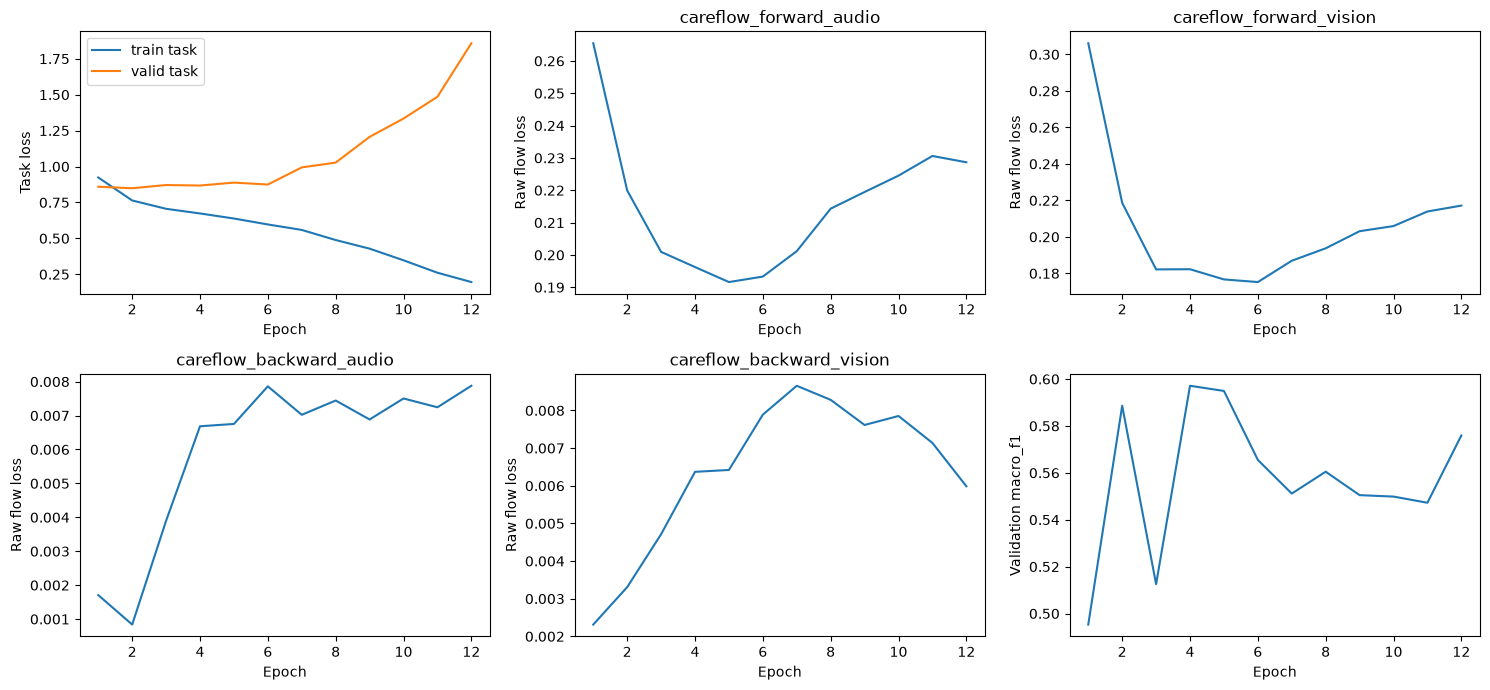

In [ ]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("曲线数据已保存在 history.json")
else:
    history = careflow_experiment.history
    epochs = [r["epoch"] for r in history]
    metric = "macro_f1" if careflow_config.task == "classification" else "mae"
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes = axes.ravel()
    axes[0].plot(epochs, [r["train_task_loss"] for r in history], label="train task")
    axes[0].plot(epochs, [r["valid"]["loss"] for r in history], label="valid task")
    axes[0].set(xlabel="Epoch", ylabel="Task loss")
    axes[0].legend()
    for axis, name in zip(axes[1:5], careflow_config.auxiliary_weights):
        axis.plot(epochs, [r["train"][name] for r in history])
        axis.set(xlabel="Epoch", ylabel="Raw flow loss", title=name)
    axes[5].plot(epochs, [r["valid"][metric] for r in history])
    axes[5].set(xlabel="Epoch", ylabel=f"Validation {metric}")
    fig.tight_layout()
    plt.show()


## 7. 原始槽位追溯与模型重载

输出目录保存来源与适配范围、配置、标准化参数、mask 审计、训练历史、最佳模型和验证／测试指标。预测文件保留样本 ID 与最终 logits，可用于实验比较；流轨迹可用上面的 `return_intermediates=True` 按需检查。

解释接口固定 mask 和目标／参照类别，替换原始缓存特征的某个模态槽位，然后重新执行编码、池化、前向流积分及融合。它返回特征替换后的预测敏感性，不是流步数的贡献，也不是因果归因或可加和的模态贡献。可使用 `id + modality + time_index` 与保留的词时间戳、原始音频和帧号关联；缓存 BERT 已传播上下文信息，若要判断原始词删除的影响，需要重新提取文本特征。


In [ ]:
careflow_explanation = explain_careflow_features(careflow_experiment, split="test", index=0)
print("解释是否重新积分流模型:", careflow_explanation["includes_flow_reintegration"])
for row in careflow_explanation["rows"][:15]:
    print(row)

careflow_model, careflow_metadata = load_careflow_model(careflow_experiment.run_dir / "best.pt")
one_sample = {key: value[:1] for key, value in data["test"].items()}
one_sample_masks = {
    m: value[:1] for m, value in (mask_overrides or {}).get("test", {}).items()
} or None
careflow_prediction = predict_careflow_split(careflow_model, one_sample, careflow_metadata, masks=one_sample_masks)
print("重载后的 logits:", careflow_prediction["logits"])


解释是否重新积分流模型: True
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 42, 'modality': 'text', 'aligned_text_token_id': 6387, 'score_drop': 0.08073902130126953, 'original_score': 3.114311695098877, 'perturbed_score': 3.0335726737976074}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 3, 'modality': 'text', 'aligned_text_token_id': 3969, 'score_drop': 0.07987165451049805, 'original_score': 3.114311695098877, 'perturbed_score': 3.034440040588379}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 43, 'modality': 'text', 'aligned_text_token_id': 8907, 'score_drop': 0.07508206367492676, 'original_score': 3.114311695098877, 'perturbed_score': 3.03922963142395}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 16, 'modality': 'text', 'aligned_text_token_id': 1010, 'score_drop': 0.07281637191772461, 'original_score': 3.114311695098877, 'perturbed_score': 3.0414953231811523}
{'id': '-AUZQgSxyPQ$_$2', 'time_index': 45, 'modality': 'text', 'aligned_text_token_id': 2096, 'score_drop': 0.06350040435791016, 'original_score': 3.114311695098

# 我们模型的融合尝试

In [1]:
import pickle
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from multi_fusion_model.this_work import (
    Config as ThisWorkConfig,
    fit_experiment as fit_this_work_experiment,
)

pkl_path = "./datasets/附件2-数据集特征文件/aligned_50.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

if "data" not in globals():
    raise RuntimeError("请先运行数据加载代码，得到 data。")
if "MODULE_DIR" not in globals():
    MODULE_DIR = str(Path.cwd() / "results" / "second_question")
if "mask_overrides" not in globals():
    mask_overrides = None

this_work_config = ThisWorkConfig(
    task="multitask",
    classification_loss_weight=1.0,
    regression_loss_weight=1.0,
    selection_metric="balanced",
    output_root=os.path.join(MODULE_DIR, "this_work"),
)

this_work_experiment = fit_this_work_experiment(
    data,
    this_work_config,
    mask_overrides=globals().get("mask_overrides"),
)

print("验证结果:", this_work_experiment.valid_metrics)
print("测试结果:", this_work_experiment.test_metrics)
print("输出目录:", this_work_experiment.run_dir)

ThisWork multitask | device=cuda | classes=[0.0, 1.0, 2.0] | output=/data_disk/disk_1/hl/workspace/huawei_cup/MultiModel-Sentiment/results/second_question/this_work/20260925_143054_487583
CE weight=1.0; MAE weight=1.0; selection=balanced; fixed MAE scale=0.835444
warmup 01 | reconstruction=1.8263
warmup 02 | reconstruction=1.3242
warmup 03 | reconstruction=1.1819
epoch 01 | CE=0.9532 | MAE=0.7724 | valid Macro-F1=0.5337 | valid MAE=0.6550
epoch 02 | CE=0.7920 | MAE=0.6480 | valid Macro-F1=0.5530 | valid MAE=0.5880
epoch 03 | CE=0.7303 | MAE=0.5847 | valid Macro-F1=0.5449 | valid MAE=0.5950
epoch 04 | CE=0.6796 | MAE=0.5446 | valid Macro-F1=0.6000 | valid MAE=0.5842
epoch 05 | CE=0.6267 | MAE=0.5067 | valid Macro-F1=0.5834 | valid MAE=0.5905
epoch 06 | CE=0.5790 | MAE=0.4875 | valid Macro-F1=0.5953 | valid MAE=0.6284
epoch 07 | CE=0.5078 | MAE=0.4528 | valid Macro-F1=0.5914 | valid MAE=0.5839
epoch 08 | CE=0.4367 | MAE=0.4256 | valid Macro-F1=0.5669 | valid MAE=0.6138
epoch 09 | CE=0.40

## 选择同一个最佳模型

没有官方综合总分，默认 balanced 是明确的实验约定：

```text
J = 0.5 × (1 − validation Macro-F1)
  + 0.5 × validation MAE / fixed_mae_scale
选择 J 最小的轮次；早停也使用这个目标。
```

fixed_mae_scale 默认取训练集“始终预测训练中位数”的 MAE（若接近零则用 1），
仅使用训练标签拟合，并写入配置和检查点。也可显式设置 selection_mae_scale。
这只是把 MAE 转换到可比较的尺度，不是比赛评分，也不保证两项一定同时提升。

selection_metric="macro_f1" 可按验证 Macro-F1 选模，"mae" 可按验证 MAE 选模；
两种设置仍然联合训练两个任务。loss 权重和选模权重分别控制训练与选择，作用不同。
最终 Macro-F1 和 MAE 始终来自同一个 best.pt；测试集只在选模完成后评价一次。